# Sprint 1

## Task 1.1: Project Setup and Data Exploration

#### Ticket 1.1.1: Set up GitHub repository with proper structure and documentation

##### 1- Create repository with README, .gitignore, and project directories (data/, notebooks/, src/)

##### 2- Document environment setup instructions

#### Ticket 1.1.2: Load and examine the dataset structure

##### 1- Import datasets and check dimensions, column types, and missing values

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from scipy import stats
import numpy as np
from matplotlib_venn import venn2
from scipy.stats import chi2_contingency
from sklearn.impute import SimpleImputer
import joblib

In [9]:
#df= pd.read_csv('../data/training_set_features.csv')

In [10]:
#train_data.head()

In [11]:
#open the datasets
submission = pd.read_csv("../data/submission_format.csv")
# print(submission)
test_features = pd.read_csv("../data/test_set_features.csv")
# print(test_features)
train_features = pd.read_csv("../data/training_set_features.csv")
# print(train_features)
train_labels = pd.read_csv("../data/training_set_labels.csv")
# print (train_labels)



In [12]:
#merge the X and Y training datasets 
train_data = train_features.merge(train_labels, on='respondent_id')
train_data.info()
train_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 13  child_under_6_mo

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


In [13]:
pd.set_option("display.max_columns", None) # desplay all the columns

In [14]:
print("Dataset dimensions:", train_data.shape) 
print("Column types:\n", train_data.dtypes)
print("Missing values:\n", train_data.isnull().sum())

Dataset dimensions: (26707, 38)
Column types:
 respondent_id                    int64
h1n1_concern                   float64
h1n1_knowledge                 float64
behavioral_antiviral_meds      float64
behavioral_avoidance           float64
behavioral_face_mask           float64
behavioral_wash_hands          float64
behavioral_large_gatherings    float64
behavioral_outside_home        float64
behavioral_touch_face          float64
doctor_recc_h1n1               float64
doctor_recc_seasonal           float64
chronic_med_condition          float64
child_under_6_months           float64
health_worker                  float64
health_insurance               float64
opinion_h1n1_vacc_effective    float64
opinion_h1n1_risk              float64
opinion_h1n1_sick_from_vacc    float64
opinion_seas_vacc_effective    float64
opinion_seas_risk              float64
opinion_seas_sick_from_vacc    float64
age_group                       object
education                       object
race             

##### 2- Create dataset profile summary

In [15]:
print("Numerical Features Summary:")
print(train_data.describe())
print("\nCategorical Features Summary:")
print(train_data.describe(include="object"))

Numerical Features Summary:
       respondent_id  h1n1_concern  h1n1_knowledge  behavioral_antiviral_meds  \
count   26707.000000  26615.000000    26591.000000               26636.000000   
mean    13353.000000      1.618486        1.262532                   0.048844   
std      7709.791156      0.910311        0.618149                   0.215545   
min         0.000000      0.000000        0.000000                   0.000000   
25%      6676.500000      1.000000        1.000000                   0.000000   
50%     13353.000000      2.000000        1.000000                   0.000000   
75%     20029.500000      2.000000        2.000000                   0.000000   
max     26706.000000      3.000000        2.000000                   1.000000   

       behavioral_avoidance  behavioral_face_mask  behavioral_wash_hands  \
count          26499.000000          26688.000000           26665.000000   
mean               0.725612              0.068982               0.825614   
std           

In [16]:
# Frequency count
for column in train_data.columns:
    print(f"Value counts for column {column}:")
    print(train_data[column].value_counts())
    print()

Value counts for column respondent_id:
respondent_id
26706    1
0        1
1        1
26690    1
26689    1
        ..
7        1
6        1
5        1
4        1
3        1
Name: count, Length: 26707, dtype: int64

Value counts for column h1n1_concern:
h1n1_concern
2.0    10575
1.0     8153
3.0     4591
0.0     3296
Name: count, dtype: int64

Value counts for column h1n1_knowledge:
h1n1_knowledge
1.0    14598
2.0     9487
0.0     2506
Name: count, dtype: int64

Value counts for column behavioral_antiviral_meds:
behavioral_antiviral_meds
0.0    25335
1.0     1301
Name: count, dtype: int64

Value counts for column behavioral_avoidance:
behavioral_avoidance
1.0    19228
0.0     7271
Name: count, dtype: int64

Value counts for column behavioral_face_mask:
behavioral_face_mask
0.0    24847
1.0     1841
Name: count, dtype: int64

Value counts for column behavioral_wash_hands:
behavioral_wash_hands
1.0    22015
0.0     4650
Name: count, dtype: int64

Value counts for column behavioral_large_

#### Ticket 1.1.3: Create summary statistics for all features

##### 1- Generate statistics for numerical and categorical features

##### 2- Check target variable distributions and class balance

In [17]:
# Check the distribution of the 'h1n1_vaccine' target variable
print("H1N1 Vaccine Distribution:")
print(train_data['h1n1_vaccine'].value_counts(normalize=True))

# Check the distribution of the 'seasonal_vaccine' target variable
print("\nSeasonal Vaccine Distribution:")
print(train_data['seasonal_vaccine'].value_counts(normalize=True))

H1N1 Vaccine Distribution:
h1n1_vaccine
0    0.787546
1    0.212454
Name: proportion, dtype: float64

Seasonal Vaccine Distribution:
seasonal_vaccine
0    0.534392
1    0.465608
Name: proportion, dtype: float64


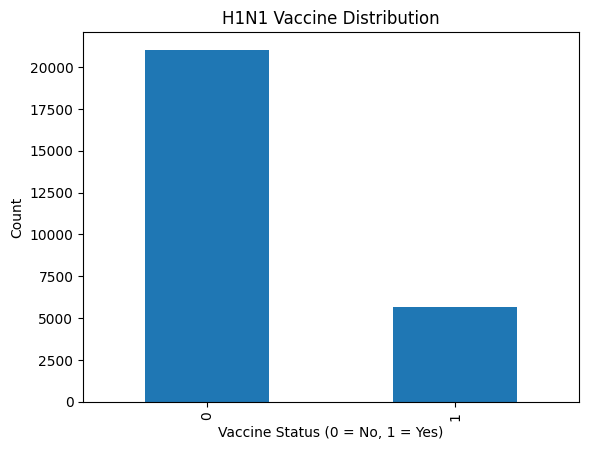

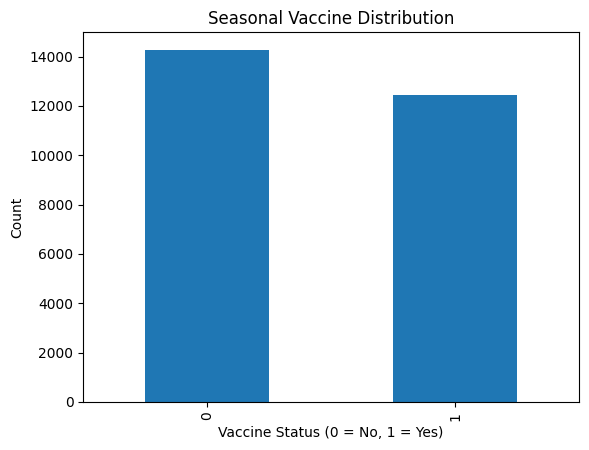

In [18]:
# Plot the distribution for 'h1n1_vaccine'
train_data['h1n1_vaccine'].value_counts().plot(kind='bar', title="H1N1 Vaccine Distribution")
plt.xlabel('Vaccine Status (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# Plot the distribution for 'seasonal_vaccine'
train_data['seasonal_vaccine'].value_counts().plot(kind='bar', title="Seasonal Vaccine Distribution")
plt.xlabel('Vaccine Status (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

#### Ticket 1.1.4: Document initial observations and questions for further investigation

##### 1- Create markdown document with key observations


##### 2- List potential challenges and questions for deeper analysis

## Task 1.2: Data Cleaning and Preprocessing

#### Ticket 1.2.1: Handle missing values

##### 1- Analyze patterns of missingness and implement appropriate imputation strategies

In [19]:
# Calculate the percentage of missing values for each feature
missing_data = train_data.isnull().sum()
missing_percentage = (missing_data / len(train_data)) * 100

In [20]:
# Print the number of missing values and their percentage
print("Missing Values Count:")
print(missing_data)
print("\nMissing Values Percentage:")
print(missing_percentage)

Missing Values Count:
respondent_id                      0
h1n1_concern                      92
h1n1_knowledge                   116
behavioral_antiviral_meds         71
behavioral_avoidance             208
behavioral_face_mask              19
behavioral_wash_hands             42
behavioral_large_gatherings       87
behavioral_outside_home           82
behavioral_touch_face            128
doctor_recc_h1n1                2160
doctor_recc_seasonal            2160
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
health_insurance               12274
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
opinion_h1n1_sick_from_vacc      395
opinion_seas_vacc_effective      462
opinion_seas_risk                514
opinion_seas_sick_from_vacc      537
age_group                          0
education                       1407
race                               0
sex                                0
income_poverty  

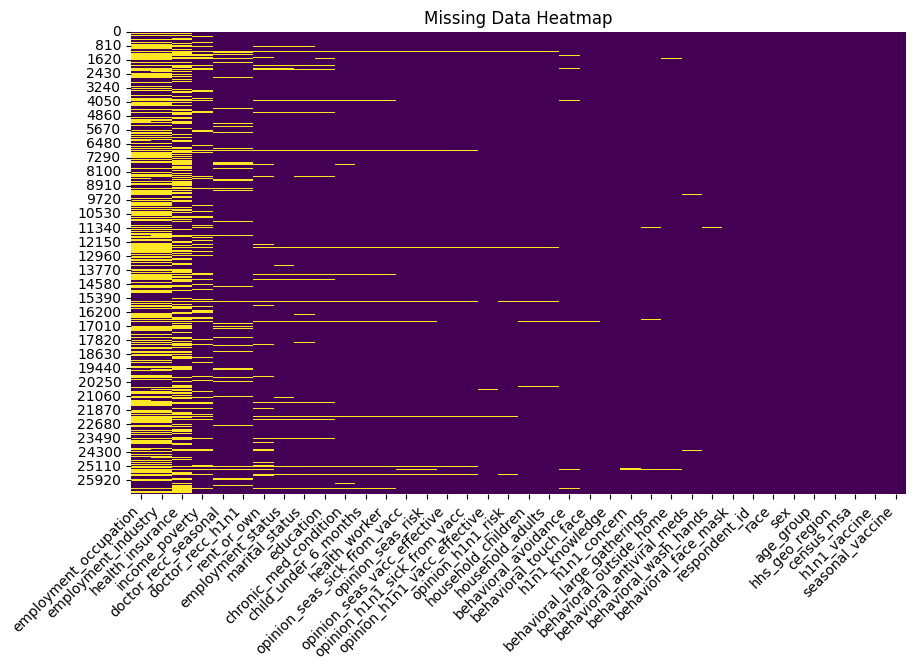

In [21]:
# Visualize missing data using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(train_data.isnull(), cbar=False, cmap="viridis")
# Sort by missing count
sorted_cols = train_data.isnull().sum().sort_values(ascending=False).index
sns.heatmap(train_data[sorted_cols].isnull(), cbar=False, cmap="viridis")
plt.xticks(rotation=45, ha='right')


plt.title('Missing Data Heatmap')
plt.show()

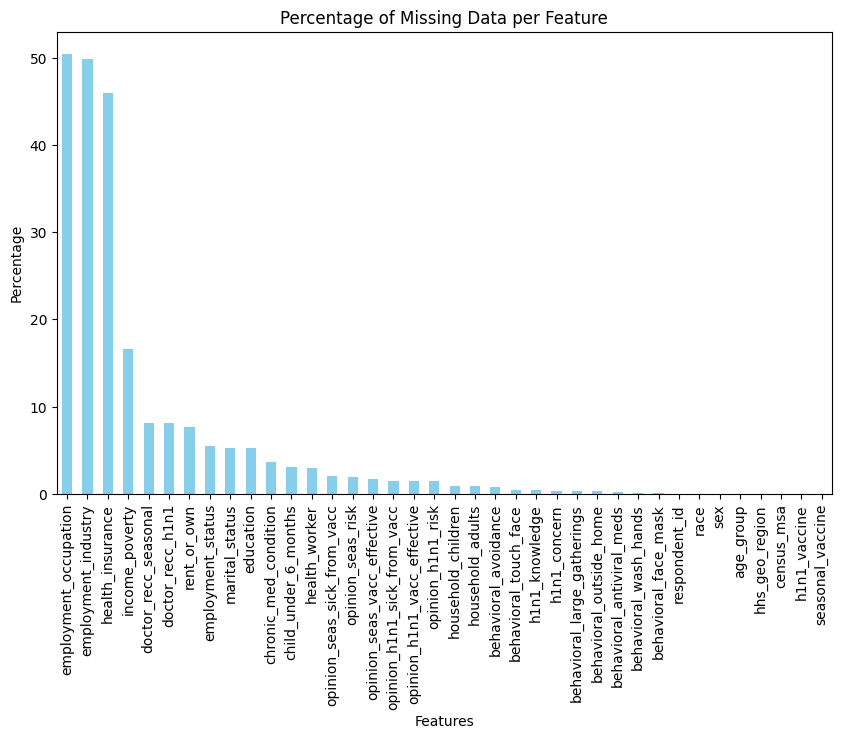

In [22]:
# Visualize the distribution of missing data per column
plt.figure(figsize=(10, 6))
missing_percentage.sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Percentage of Missing Data per Feature')
plt.ylabel('Percentage')
plt.xlabel('Features')
plt.show()

In [23]:
# Colomn types
ordinal_cols = [
    'h1n1_concern', 'h1n1_knowledge', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
    'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc'
]
binary_cols = [
    'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
    'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'chronic_med_condition',
    'child_under_6_months', 'health_worker', 'health_insurance', 'doctor_recc_h1n1', 'doctor_recc_seasonal'
]
numerical_cols = ['household_adults', 'household_children']
categorical_cols = [
    'age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own',
    'employment_status', 'hhs_geo_region', 'census_msa', 'employment_industry', 'employment_occupation'
]

# Imputation pipeline
imputer = ColumnTransformer([
    ('ordinal_mode', SimpleImputer(strategy='most_frequent'), ordinal_cols),  # Mode for low-missing ordinal (e.g., h1n1_concern = 2)
    ('binary_mode', SimpleImputer(strategy='most_frequent'), [col for col in binary_cols if col not in ['doctor_recc_h1n1', 'doctor_recc_seasonal']]),  # Mode for health_insurance (1), health_worker (0), etc.
    ('binary_zero', SimpleImputer(strategy='constant', fill_value=0), ['doctor_recc_h1n1', 'doctor_recc_seasonal']),  # 0 for doctor recs (~80% non-missing = 0)
    ('numerical_median', SimpleImputer(strategy='median'), numerical_cols),  # Median for household (~0.9, ~0.5)
    ('cat_mode', SimpleImputer(strategy='most_frequent'), [col for col in categorical_cols if col not in ['employment_industry', 'employment_occupation']]),  # Mode for education, income_poverty, etc.
    ('cat_missing', SimpleImputer(strategy='constant', fill_value='Not Applicable'), ['employment_industry', 'employment_occupation'])  # Not Applicable for ~50% missing
], remainder='passthrough')  # Keep respondent_id, targets

# Apply imputation
train_imputed = imputer.fit_transform(train_data)
# Reconstruct DataFrame with correct column order
all_cols = (ordinal_cols + 
            [col for col in binary_cols if col not in ['doctor_recc_h1n1', 'doctor_recc_seasonal']] + 
            ['doctor_recc_h1n1', 'doctor_recc_seasonal'] + 
            numerical_cols + 
            [col for col in categorical_cols if col not in ['employment_industry', 'employment_occupation']] + 
            ['employment_industry', 'employment_occupation'] + 
            ['respondent_id', 'h1n1_vaccine', 'seasonal_vaccine'])
train_imputed_df = pd.DataFrame(train_imputed, columns=all_cols)

# Restore dtypes (imputation may cast to float/object)
for col in ordinal_cols + binary_cols:
    train_imputed_df[col] = pd.to_numeric(train_imputed_df[col], errors='coerce').astype(int)  # Integer for 0/1 or ordinal
for col in numerical_cols:
    train_imputed_df[col] = pd.to_numeric(train_imputed_df[col], errors='coerce').astype(float)  # Float for median
for col in categorical_cols:
    train_imputed_df[col] = train_imputed_df[col].astype(str)
train_imputed_df['respondent_id'] = train_imputed_df['respondent_id'].astype(int)
train_imputed_df['h1n1_vaccine'] = train_imputed_df['h1n1_vaccine'].astype(int)
train_imputed_df['seasonal_vaccine'] = train_imputed_df['seasonal_vaccine'].astype(int)

# Save imputed data
train_imputed_df.to_csv('train_data_imputed.csv', index=False)
print("Imputed data saved as 'train_data_imputed.csv'")

# Save pipeline for test set (Task 1.2.5)
joblib.dump(imputer, 'imputer_pipeline.pkl')
print("Imputer pipeline saved as 'imputer_pipeline.pkl'")



Imputed data saved as 'train_data_imputed.csv'
Imputer pipeline saved as 'imputer_pipeline.pkl'


##### 2- Document rationale for each imputation decision

#Document rationale for each imputation decision

Ordinal: Mode to preserve discrete scales .
Binary:
Mode for most to retain predictive power.
0 for doctor_recc_h1n1, doctor_recc_seasonal (missing likely no recommendation).
Numerical (household_adults, household_children): Median for robustness.
Categorical:
Mode for low missingness
"Not Applicable" for employment_industry, employment_occupation ( around 50% missing) to capture unemployment signal.

#### Ticket 1.2.2: Convert categorical variables to appropriate formats

##### 1- Apply encoding techniques (one-hot, label, ordinal) based on variable type

In [24]:
train_data.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


In [25]:

# Frequency count
for col in ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 
            'employment_status', 'hhs_geo_region', 'census_msa', 'employment_industry', 'employment_occupation']:
    print(f"Value counts for {col}:")
    print(train_data[col].value_counts())
    print("-" * 30)


Value counts for age_group:
age_group
65+ Years        6843
55 - 64 Years    5563
45 - 54 Years    5238
18 - 34 Years    5215
35 - 44 Years    3848
Name: count, dtype: int64
------------------------------
Value counts for education:
education
College Graduate    10097
Some College         7043
12 Years             5797
< 12 Years           2363
Name: count, dtype: int64
------------------------------
Value counts for race:
race
White                21222
Black                 2118
Hispanic              1755
Other or Multiple     1612
Name: count, dtype: int64
------------------------------
Value counts for sex:
sex
Female    15858
Male      10849
Name: count, dtype: int64
------------------------------
Value counts for income_poverty:
income_poverty
<= $75,000, Above Poverty    12777
> $75,000                     6810
Below Poverty                 2697
Name: count, dtype: int64
------------------------------
Value counts for marital_status:
marital_status
Married        13555
Not Marri

In [26]:
-------------------------------------
from sklearn.preprocessing import OrdinalEncoder

# Define variable groups
ordinal_cols = ['age_group', 'education', 'income_poverty']
binary_cols = ['sex', 'marital_status', 'rent_or_own']
nominal_cols = ['race', 'hhs_geo_region', 'census_msa', 'employment_industry', 'employment_occupation', 'employment_status']

# Define custom orderings for ordinal columns
age_order = ['18 - 34 Years', '35 - 44 Years', '45 - 54 Years', '55 - 64 Years', '65+ Years']
edu_order = ['< 12 Years', '12 Years', 'Some College', 'College Graduate']
income_order = ['Below Poverty', '<= $75,000, Above Poverty', '> $75,000']

# Apply Ordinal Encoding
ordinal_mapping = OrdinalEncoder(categories=[age_order, edu_order, income_order])
train_data[ordinal_cols] = ordinal_mapping.fit_transform(train_data[ordinal_cols])

# Apply Label Encoding to binary (2-class) categorical variables
label_enc = LabelEncoder()
for col in binary_cols:
    train_data[col] = label_enc.fit_transform(train_data[col])

# One-Hot Encode nominal categorical columns
train_data = pd.get_dummies(train_data, columns=nominal_cols, drop_first=True)

print("Encoding complete. New shape:", train_data.shape)


SyntaxError: invalid syntax (3910311731.py, line 1)

In [27]:
train_data.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


##### 2- Implement appropriate treatment strategies and document impact

#Encoding summary

Ordinal Encoding (Order Matters)
-age_group  
-education 
-income_poverty

Label Encoding (Binary)
-sex  
-marital_status 
-rent_or_own 


One-Hot Encoding (No Order, Many Categories)
-race  
-hhs_geo_region 
-census_msa 
-employment_industry 
-employment_occupation
-employment_status

#### Ticket 1.2.3: Check for and handle outliers if necessary

Checking for Numerical Continuous variables


In [29]:

print(f"Summary before removing outliers for {col}:\n", train_data.describe())

Summary before removing outliers for employment_occupation:
        respondent_id  h1n1_concern  h1n1_knowledge  behavioral_antiviral_meds  \
count   26707.000000  26615.000000    26591.000000               26636.000000   
mean    13353.000000      1.618486        1.262532                   0.048844   
std      7709.791156      0.910311        0.618149                   0.215545   
min         0.000000      0.000000        0.000000                   0.000000   
25%      6676.500000      1.000000        1.000000                   0.000000   
50%     13353.000000      2.000000        1.000000                   0.000000   
75%     20029.500000      2.000000        2.000000                   0.000000   
max     26706.000000      3.000000        2.000000                   1.000000   

       behavioral_avoidance  behavioral_face_mask  behavioral_wash_hands  \
count          26499.000000          26688.000000           26665.000000   
mean               0.725612              0.068982        

In [30]:
# Frequency count
for col in ['h1n1_concern', 'h1n1_knowledge', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group', 'education', 'income_poverty', 'household_adults', 'household_children']:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())
    print("-" * 30)


Value counts for h1n1_concern:
h1n1_concern
2.0    10575
1.0     8153
3.0     4591
0.0     3296
Name: count, dtype: int64
------------------------------
Value counts for h1n1_knowledge:
h1n1_knowledge
1.0    14598
2.0     9487
0.0     2506
Name: count, dtype: int64
------------------------------
Value counts for opinion_h1n1_vacc_effective:
opinion_h1n1_vacc_effective
4.0    11683
5.0     7166
3.0     4723
2.0     1858
1.0      886
Name: count, dtype: int64
------------------------------
Value counts for opinion_h1n1_risk:
opinion_h1n1_risk
2.0    9919
1.0    8139
4.0    5394
5.0    1750
3.0    1117
Name: count, dtype: int64
------------------------------
Value counts for opinion_h1n1_sick_from_vacc:
opinion_h1n1_sick_from_vacc
2.0    9129
1.0    8998
4.0    5850
5.0    2187
3.0     148
Name: count, dtype: int64
------------------------------
Value counts for opinion_seas_vacc_effective:
opinion_seas_vacc_effective
4.0    11629
5.0     9973
2.0     2206
1.0     1221
3.0     1216
Name: 

--------------------------------------------------
#Keeping the code for detecting and dealing with outliers just in casse here

#Select float64 columns
float_cols = train_data.select_dtypes(include='float64').columns

#Exclude binary float columns (only 2 unique values, because for outlyer analysis we can't use dummies)
non_binary_float_cols = [col for col in float_cols if train_data[col].nunique() > 2]

print("Float columns (excluding binary) for outlier analysis:")
print(non_binary_float_cols)


#Visualizing the outlyers
for col in float_cols:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=train_data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

for col in float_cols:
    train_data[col].hist(bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

    
 #IQR (Interquartile Range) method to flag potential outliers
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

#Apply across all float columns
for col in float_cols:
    outliers = detect_outliers_iqr(train_data, col)
    print(f"{col}: {len(outliers)} outliers")


columns_with_outliers = ['']

#Apply Winsorization (Capping)
def cap_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[col] = np.where(data[col] < lower_bound, lower_bound,
                         np.where(data[col] > upper_bound, upper_bound, data[col]))
    return data

#Apply to selected columns
for col in columns_with_outliers:
    train_data = cap_outliers(train_data, col)


#Summary comparison table
#Store before-treatment stats
summary_before = {}

#Recalculate for columns only
for col in columns_with_outliers:
    summary_before[col] = train_data[col].describe()

#After treatment
print("\n=== IMPACT OF OUTLIER TREATMENT ===")
for col in columns_with_outliers:
    print(f"\n {col}")
    print("Before Treatment:")
    print(summary_before[col])
    print("\nAfter Treatment:")
    print(train_data[col].describe())



#### Ticket 1.2.4: Normalize/standardize numerical features if appropriate

##### 1- Apply scaling techniques based on data characteristics

##### 2- Create reusable scalers for test data

Summary for outliers analysis:
    We can apply outliers analysis only to continues numerical variables, and since the variables in the dataset are not continuous numerical, I guess we can skip this step. 

## Task 1.3: Exploratory Visualization

#### Ticket 1.3.1: Create visualizations for the distribution of target variables

##### 1- Generate charts showing H1N1 and seasonal vaccination rates

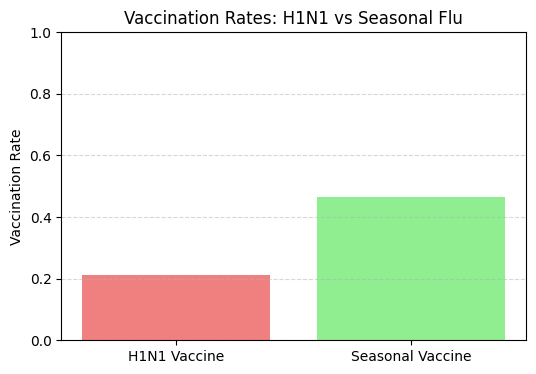

In [31]:
# Calculate vaccination rates (the proportion of people who got the vaccine)
h1n1_rate = train_data['h1n1_vaccine'].mean()
seasonal_rate = train_data['seasonal_vaccine'].mean()

# Plot
plt.figure(figsize=(6,4))
plt.bar(['H1N1 Vaccine', 'Seasonal Vaccine'], [h1n1_rate, seasonal_rate], color=['lightcoral', 'lightgreen'])
plt.ylim(0, 1)
plt.ylabel('Vaccination Rate')
plt.title('Vaccination Rates: H1N1 vs Seasonal Flu')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

##### 2- Visualize overlap between the two vaccination types

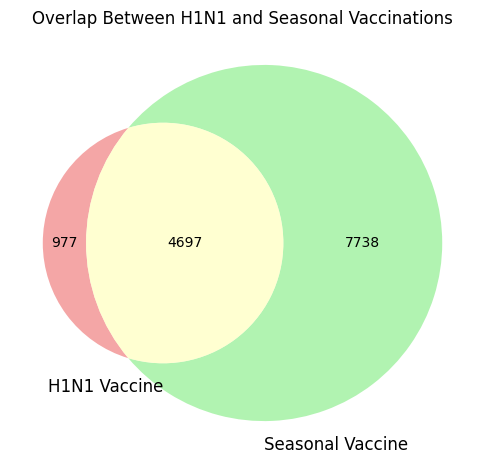

In [32]:
# Count each group
only_h1n1 = ((train_data['h1n1_vaccine'] == 1) & (train_data['seasonal_vaccine'] == 0)).sum()
only_seasonal = ((train_data['h1n1_vaccine'] == 0) & (train_data['seasonal_vaccine'] == 1)).sum()
both = ((train_data['h1n1_vaccine'] == 1) & (train_data['seasonal_vaccine'] == 1)).sum()

# Plot Venn
plt.figure(figsize=(6,6))
venn2(subsets=(only_h1n1, only_seasonal, both), 
      set_labels=('H1N1 Vaccine', 'Seasonal Vaccine'),
      set_colors=('lightcoral', 'lightgreen'), alpha=0.7)
plt.title("Overlap Between H1N1 and Seasonal Vaccinations")
plt.show()

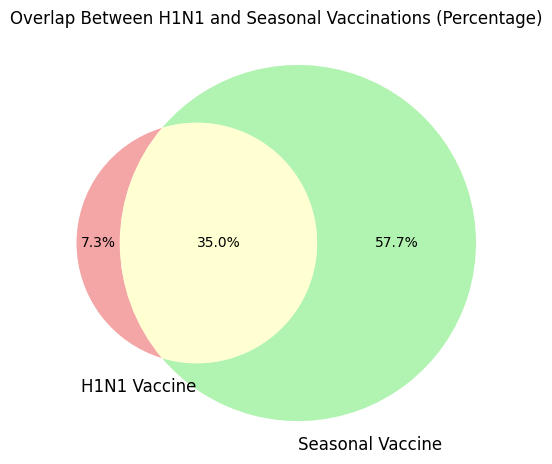

In [33]:
# Count each group
only_h1n1 = ((train_data['h1n1_vaccine'] == 1) & (train_data['seasonal_vaccine'] == 0)).sum()
only_seasonal = ((train_data['h1n1_vaccine'] == 0) & (train_data['seasonal_vaccine'] == 1)).sum()
both = ((train_data['h1n1_vaccine'] == 1) & (train_data['seasonal_vaccine'] == 1)).sum()

# Total number of relevant samples (only ones that took at least one vaccine)
total = only_h1n1 + only_seasonal + both

# Convert to percentages
only_h1n1_pct = only_h1n1 / total * 100
only_seasonal_pct = only_seasonal / total * 100
both_pct = both / total * 100

# Plot Venn with percentages
plt.figure(figsize=(6, 6))
venn = venn2(subsets=(only_h1n1_pct, only_seasonal_pct, both_pct), 
             set_labels=('H1N1 Vaccine', 'Seasonal Vaccine'),
             set_colors=('lightcoral', 'lightgreen'), alpha=0.7)

# Format the labels to show percentages
for idx in ['10', '01', '11']:  # '10' = only A, '01' = only B, '11' = both
    if venn.get_label_by_id(idx):
        label_value = float(venn.get_label_by_id(idx).get_text())
        venn.get_label_by_id(idx).set_text(f"{label_value:.1f}%")

plt.title("Overlap Between H1N1 and Seasonal Vaccinations (Percentage)")
plt.show()

#### Ticket 1.3.2: Visualize relationships between demographic variables and vaccination rates

##### 1- Create grouped bar charts and heatmaps by demographic variables

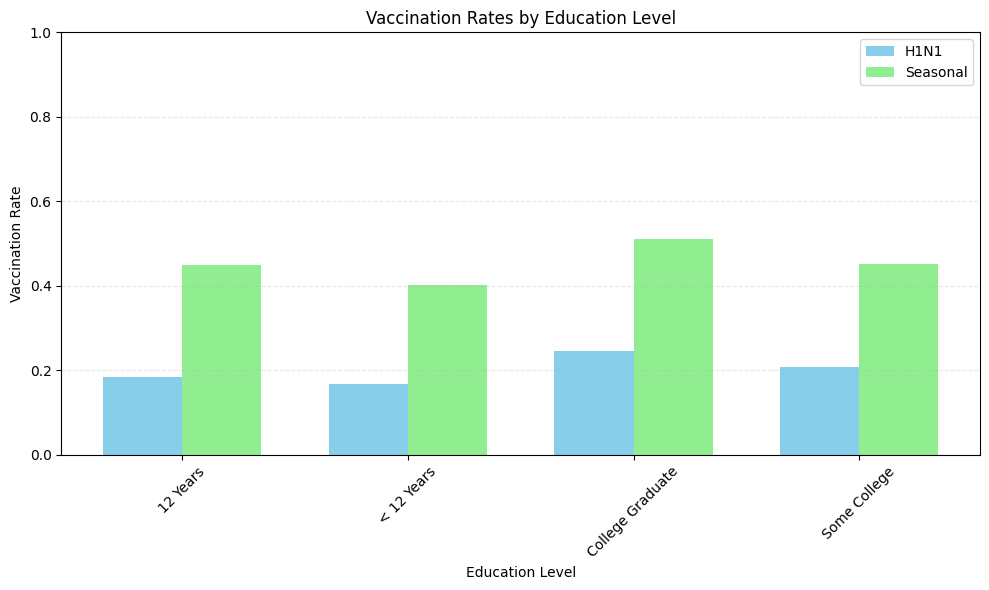

In [34]:

# Group by education and calculate mean vaccination rates
grouped_edu = train_data.groupby('education')[['h1n1_vaccine', 'seasonal_vaccine']].mean()

# Bar positions
x = np.arange(len(grouped_edu))
width = 0.35

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, grouped_edu['h1n1_vaccine'], width, label='H1N1', color='skyblue')
ax.bar(x + width/2, grouped_edu['seasonal_vaccine'], width, label='Seasonal', color='lightgreen')

# Labels and formatting
ax.set_ylabel('Vaccination Rate')
ax.set_xlabel('Education Level')  #X-axis label
ax.set_title('Vaccination Rates by Education Level')
ax.set_xticks(x)
ax.set_xticklabels(grouped_edu.index, rotation=45)
ax.set_ylim(0, 1)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

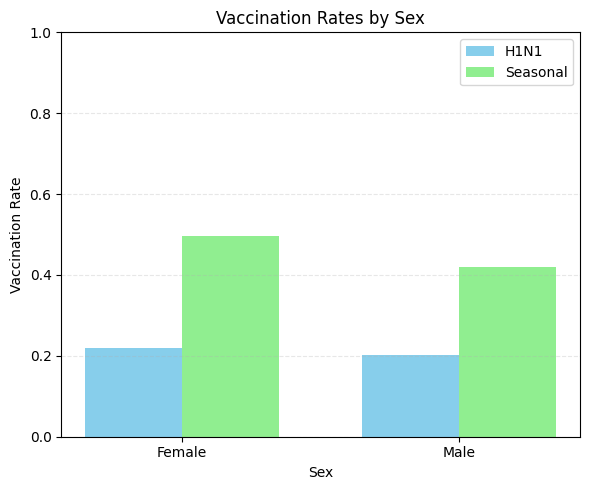

In [35]:
#Grouped bar charts for gender
grouped_sex = train_data.groupby('sex')[['h1n1_vaccine', 'seasonal_vaccine']].mean()
x = np.arange(len(grouped_sex))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(x - width/2, grouped_sex['h1n1_vaccine'], width, label='H1N1', color='skyblue')
ax.bar(x + width/2, grouped_sex['seasonal_vaccine'], width, label='Seasonal', color='lightgreen')

ax.set_ylabel('Vaccination Rate')
ax.set_xlabel('Sex')
ax.set_title('Vaccination Rates by Sex')
ax.set_xticks(x)
ax.set_xticklabels(grouped_sex.index)
ax.set_ylim(0, 1)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


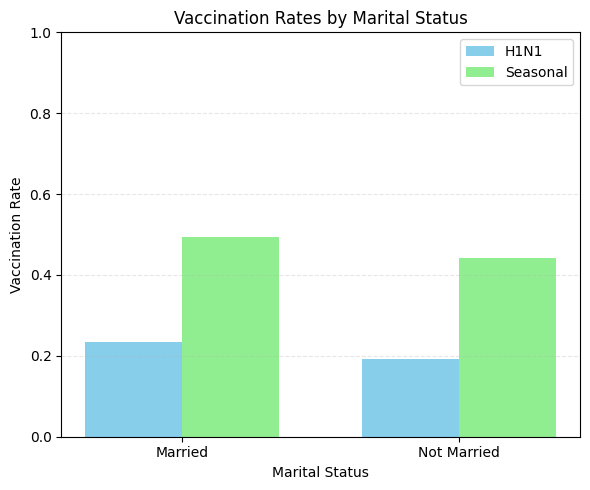

In [36]:
#Grouped bar charts for marital status

grouped_marital = train_data.groupby('marital_status')[['h1n1_vaccine', 'seasonal_vaccine']].mean()
x = np.arange(len(grouped_marital))

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(x - width/2, grouped_marital['h1n1_vaccine'], width, label='H1N1', color='skyblue')
ax.bar(x + width/2, grouped_marital['seasonal_vaccine'], width, label='Seasonal', color='lightgreen')

ax.set_ylabel('Vaccination Rate')
ax.set_xlabel('Marital Status')
ax.set_title('Vaccination Rates by Marital Status')
ax.set_xticks(x)
ax.set_xticklabels(grouped_marital.index)
ax.set_ylim(0, 1)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

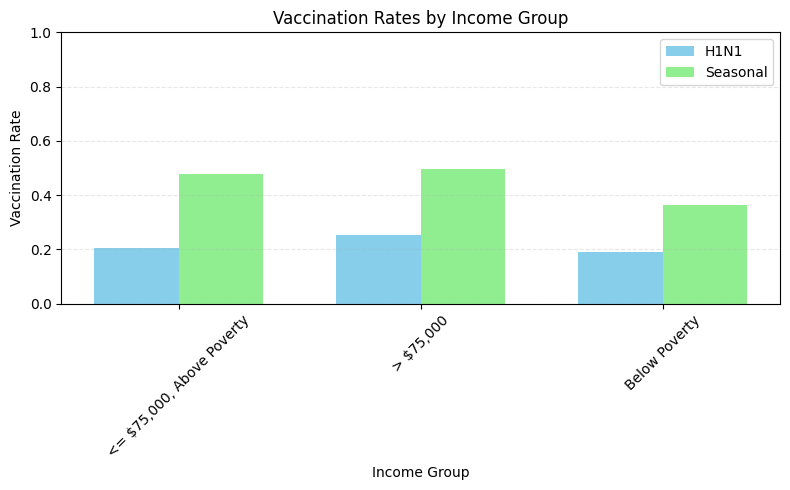

In [37]:
#Grouped bar charts for Income Group
grouped_income = train_data.groupby('income_poverty')[['h1n1_vaccine', 'seasonal_vaccine']].mean()
x = np.arange(len(grouped_income))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, grouped_income['h1n1_vaccine'], width, label='H1N1', color='skyblue')
ax.bar(x + width/2, grouped_income['seasonal_vaccine'], width, label='Seasonal', color='lightgreen')

ax.set_ylabel('Vaccination Rate')
ax.set_xlabel('Income Group')
ax.set_title('Vaccination Rates by Income Group')
ax.set_xticks(x)
ax.set_xticklabels(grouped_income.index, rotation=45)
ax.set_ylim(0, 1)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

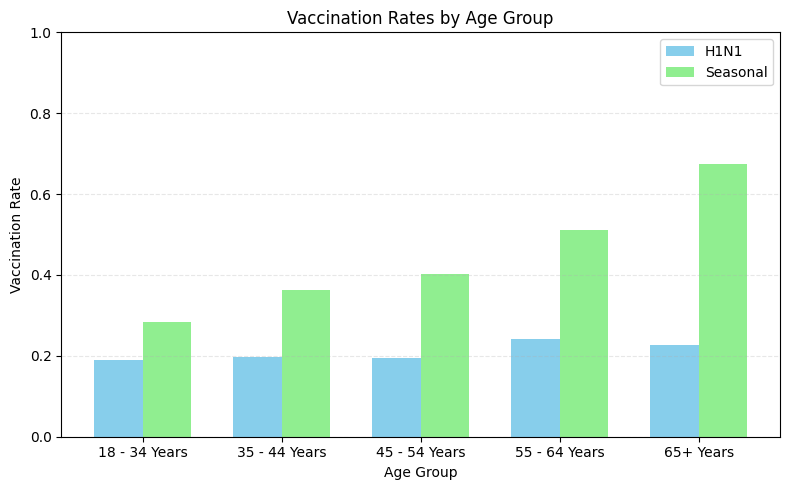

In [38]:
#Grouped bar charts for Age Group
grouped_age = train_data.groupby('age_group')[['h1n1_vaccine', 'seasonal_vaccine']].mean()
x = np.arange(len(grouped_age))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, grouped_age['h1n1_vaccine'], width, label='H1N1', color='skyblue')
ax.bar(x + width/2, grouped_age['seasonal_vaccine'], width, label='Seasonal', color='lightgreen')

ax.set_ylabel('Vaccination Rate')
ax.set_xlabel('Age Group')
ax.set_title('Vaccination Rates by Age Group')
ax.set_xticks(x)
ax.set_xticklabels(grouped_age.index)
ax.set_ylim(0, 1)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


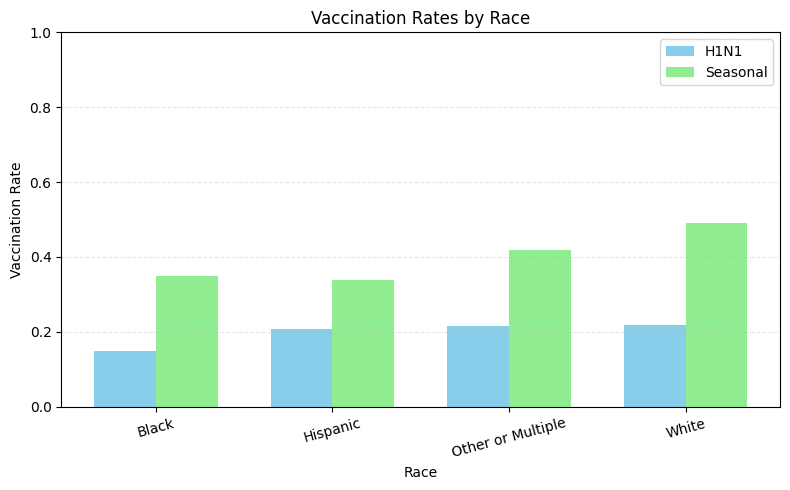

In [39]:
#Grouped bar charts for Race
grouped_race = train_data.groupby('race')[['h1n1_vaccine', 'seasonal_vaccine']].mean()
x = np.arange(len(grouped_race))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, grouped_race['h1n1_vaccine'], width, label='H1N1', color='skyblue')
ax.bar(x + width/2, grouped_race['seasonal_vaccine'], width, label='Seasonal', color='lightgreen')

ax.set_ylabel('Vaccination Rate')
ax.set_xlabel('Race')
ax.set_title('Vaccination Rates by Race')
ax.set_xticks(x)
ax.set_xticklabels(grouped_race.index, rotation=15)
ax.set_ylim(0, 1)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

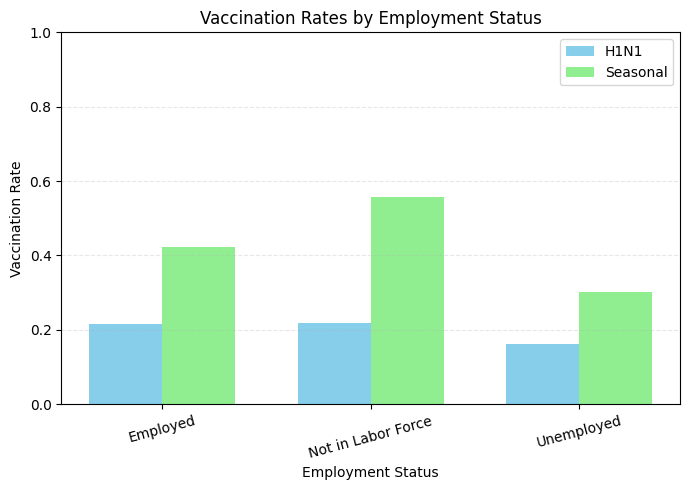

In [40]:
#Grouped bar charts for Employment Status
grouped_emp = train_data.groupby('employment_status')[['h1n1_vaccine', 'seasonal_vaccine']].mean()
x = np.arange(len(grouped_emp))

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, grouped_emp['h1n1_vaccine'], width, label='H1N1', color='skyblue')
ax.bar(x + width/2, grouped_emp['seasonal_vaccine'], width, label='Seasonal', color='lightgreen')

ax.set_ylabel('Vaccination Rate')
ax.set_xlabel('Employment Status')
ax.set_title('Vaccination Rates by Employment Status')
ax.set_xticks(x)
ax.set_xticklabels(grouped_emp.index, rotation=15)
ax.set_ylim(0, 1)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_heatmap(data, index_var, column_var, vaccine_col='h1n1_vaccine'):
    pivot = data.pivot_table(index=index_var, columns=column_var, values=vaccine_col, aggfunc='mean')
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap='YlGnBu', cbar_kws={'label': f'{vaccine_col.replace("_", " ").title()} Rate'})
    plt.title(f'{vaccine_col.replace("_", " ").title()} Rate by {index_var.replace("_", " ").title()} and {column_var.replace("_", " ").title()}')
    plt.xlabel(column_var.replace('_', ' ').title())
    plt.ylabel(index_var.replace('_', ' ').title())
    plt.tight_layout()
    plt.show()


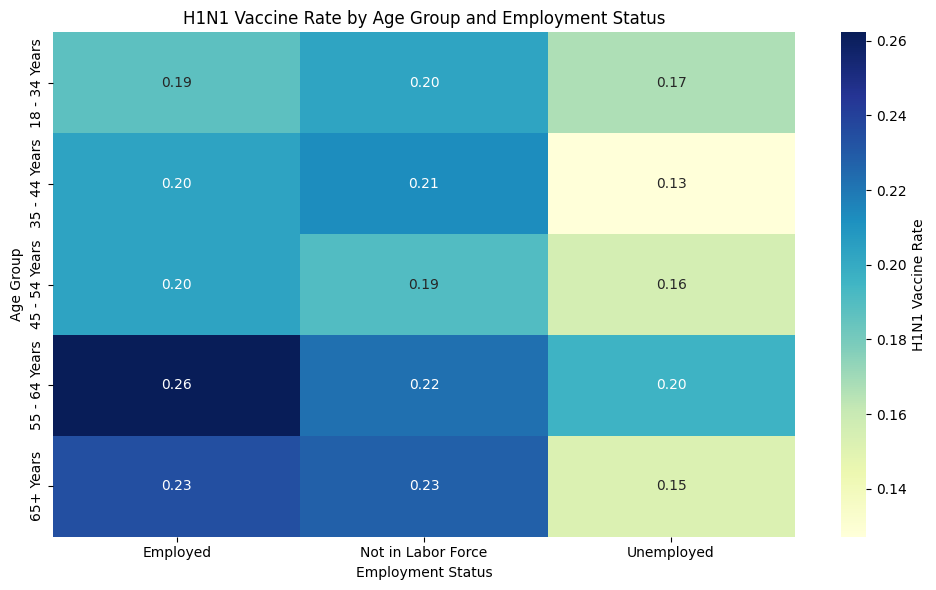

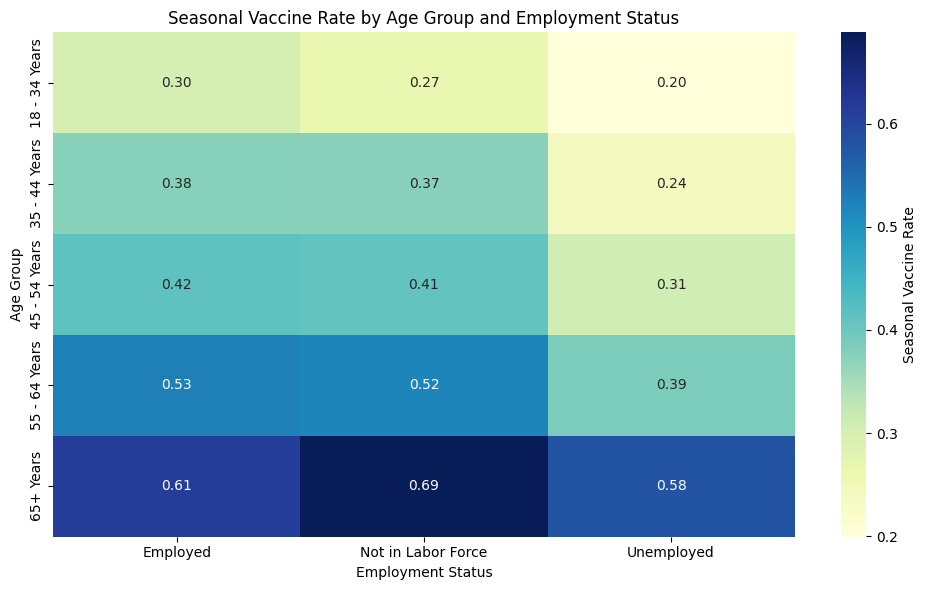

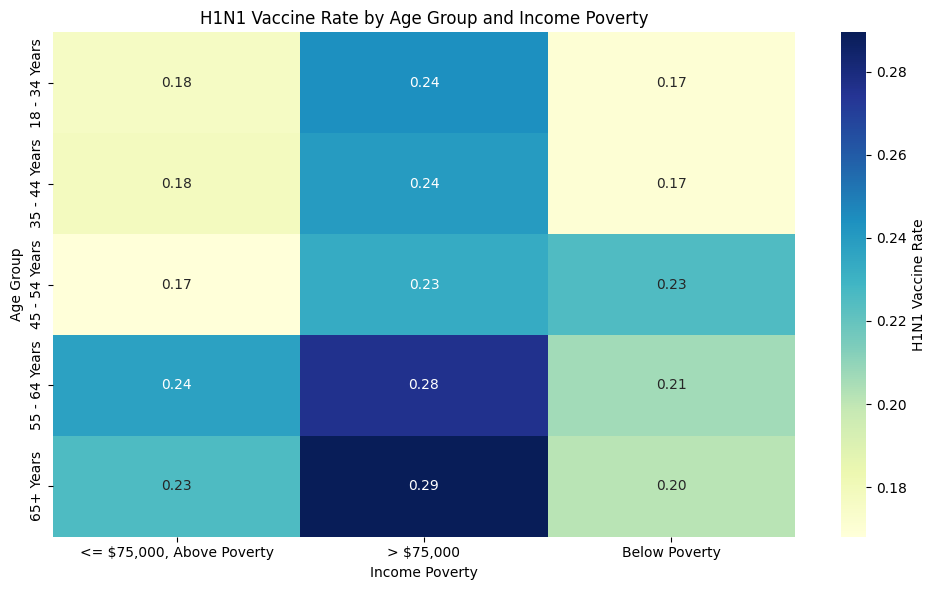

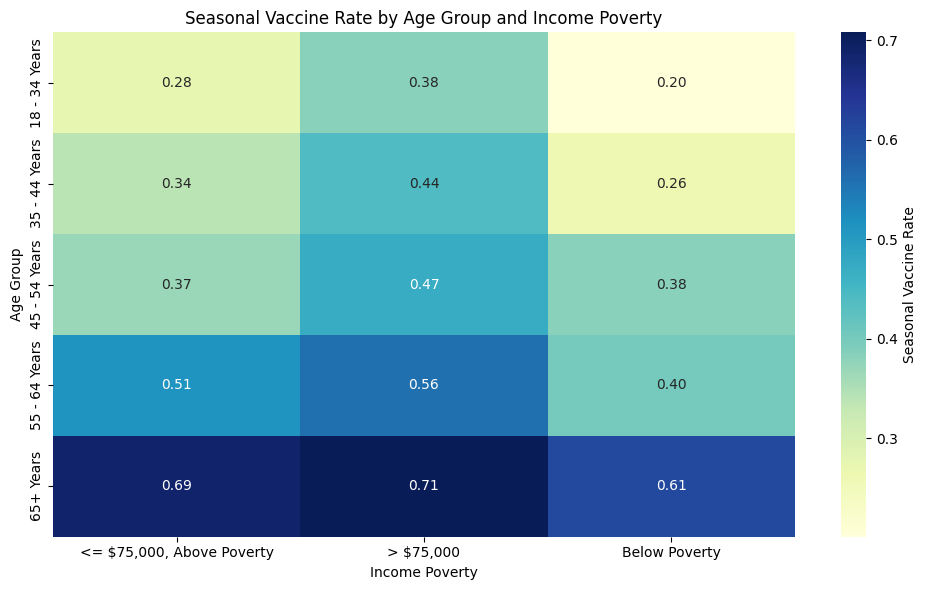

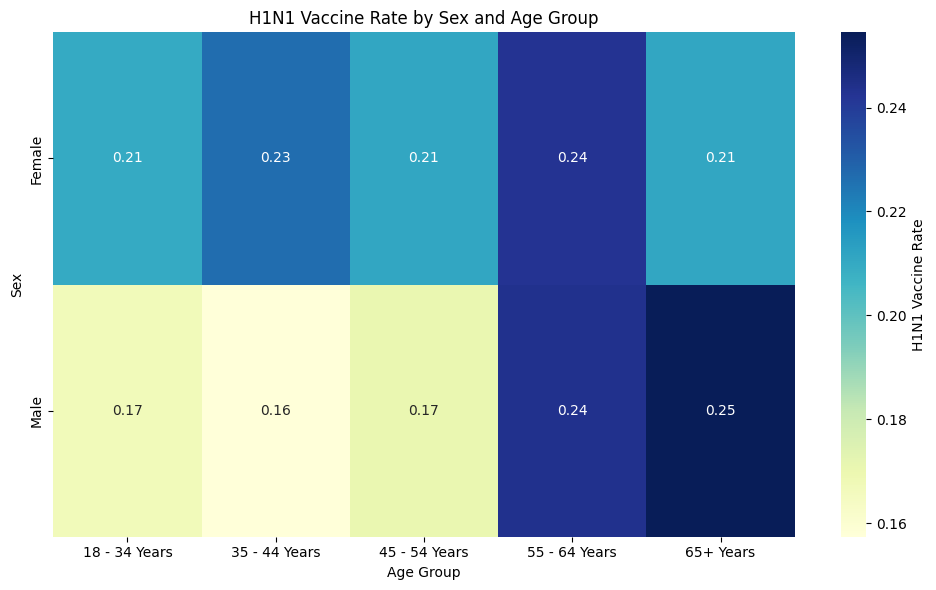

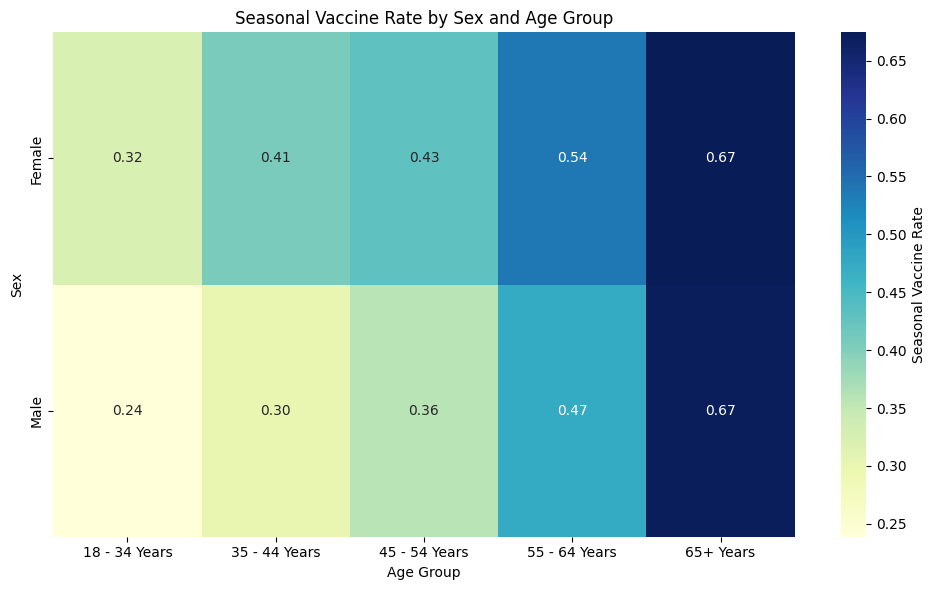

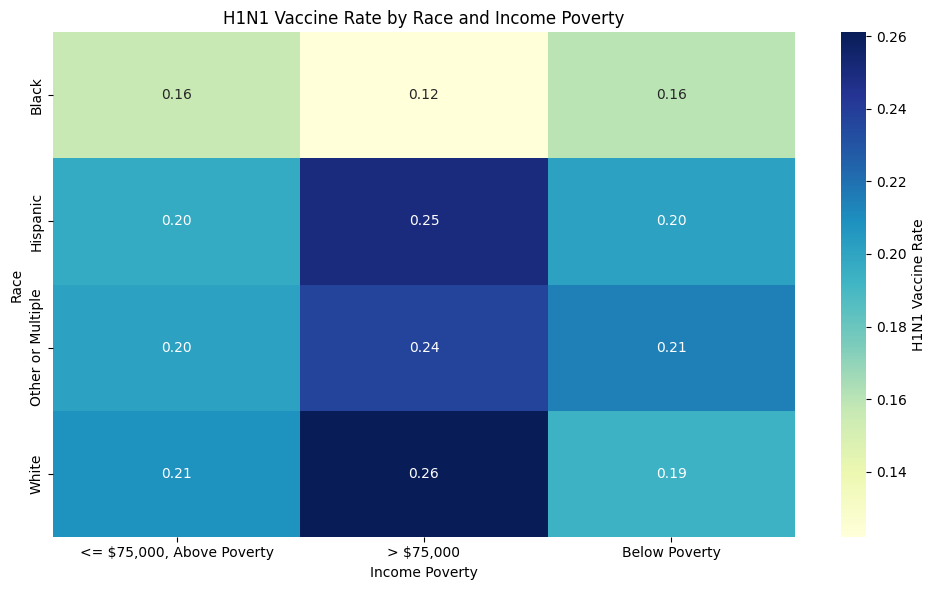

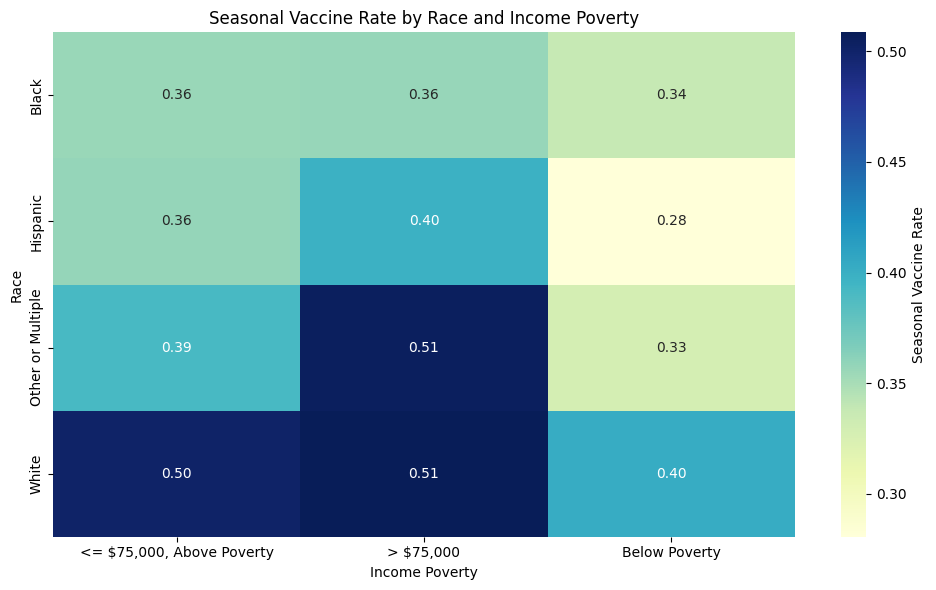

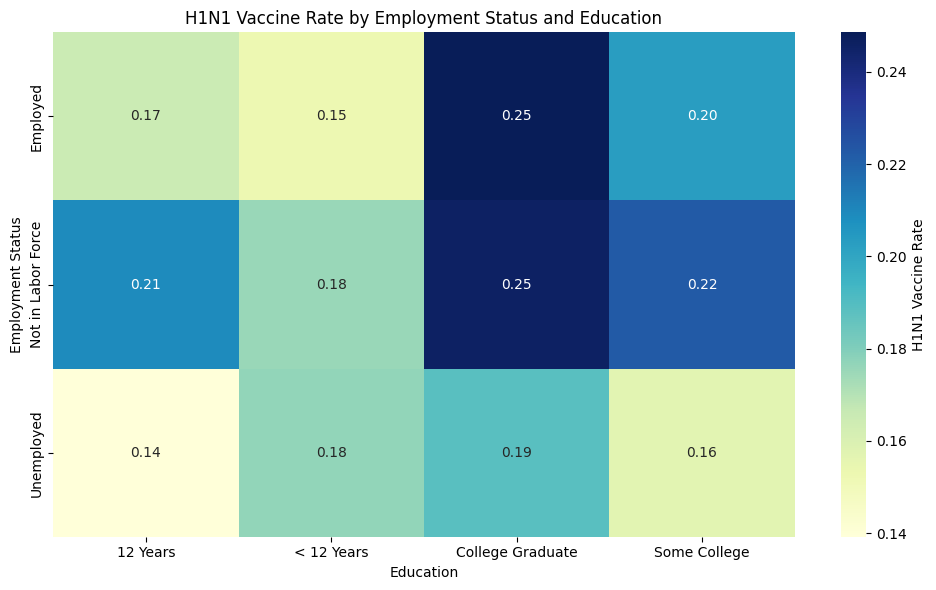

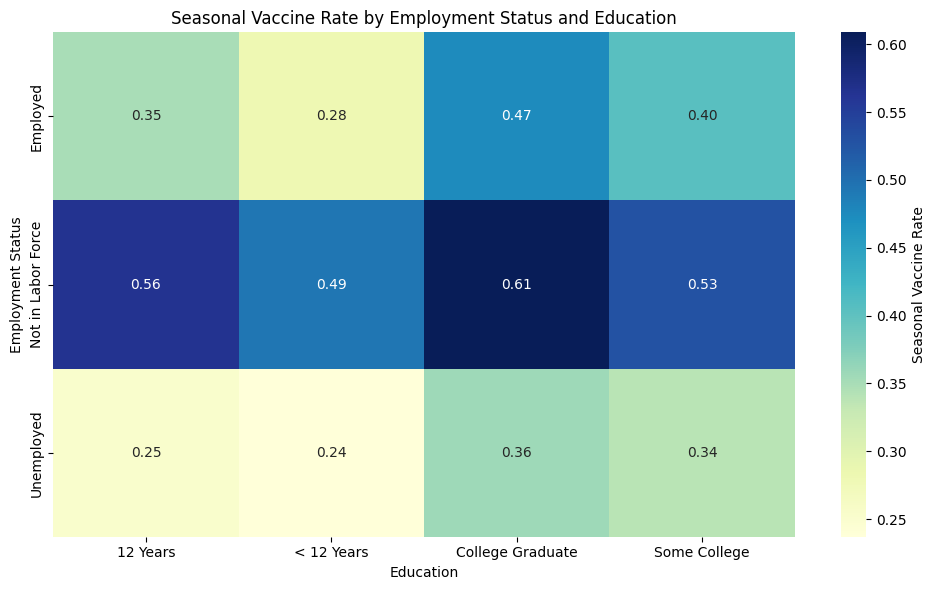

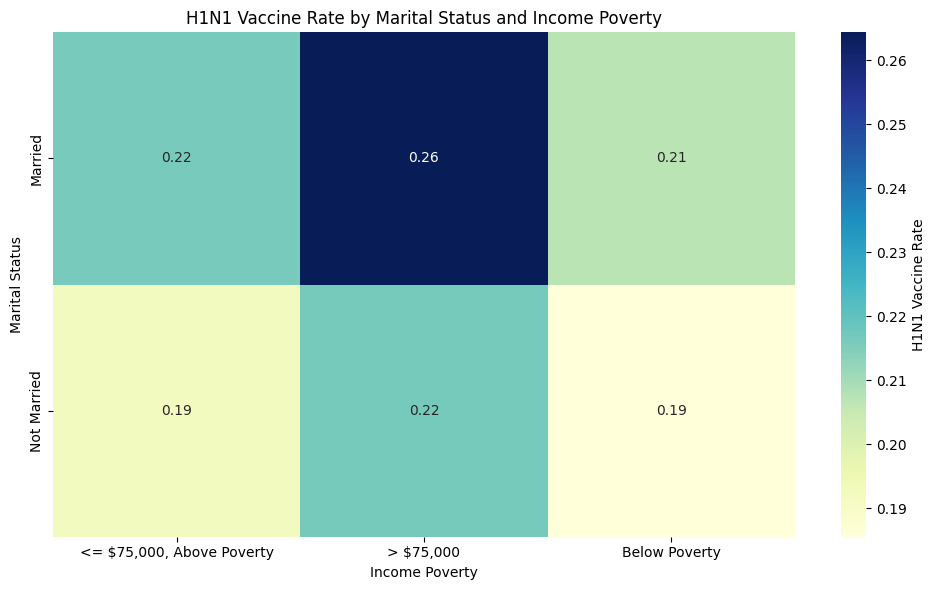

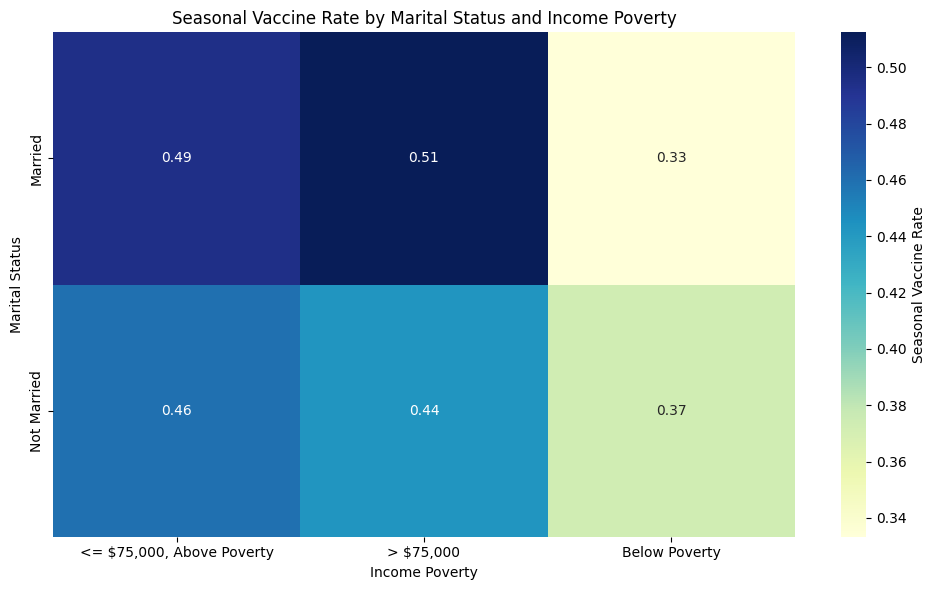

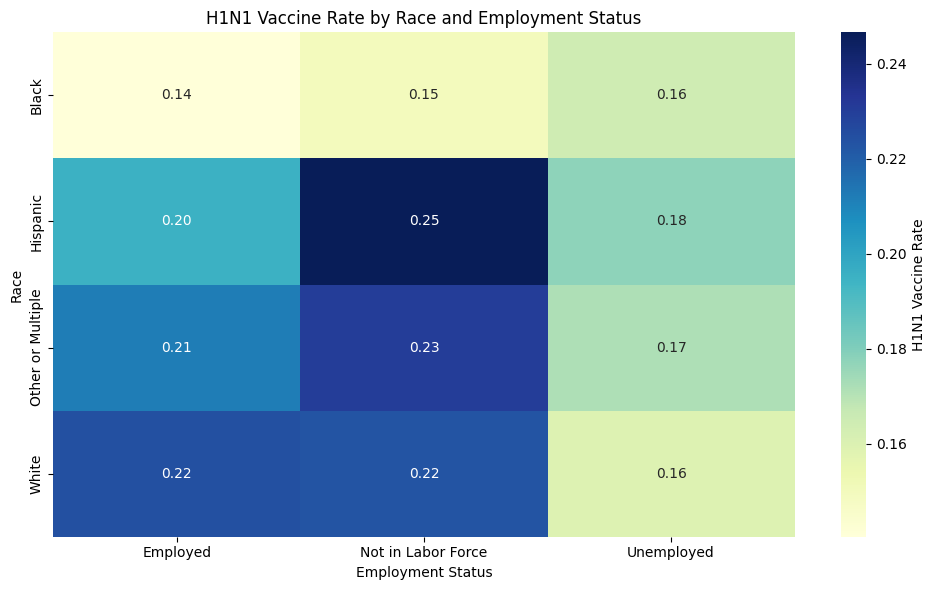

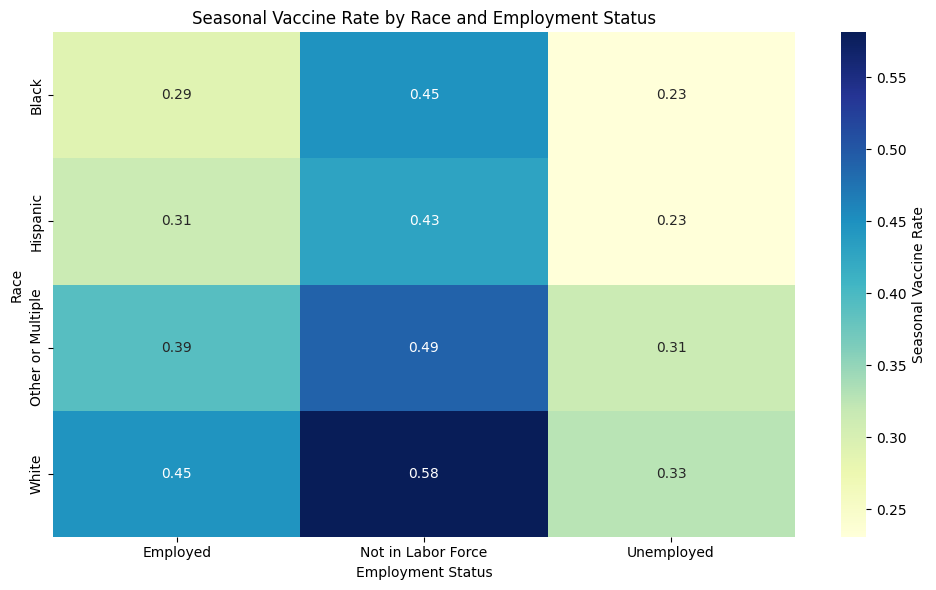

In [42]:
heatmap_combos = [
    ('age_group', 'employment_status'),
    ('age_group', 'income_poverty'),
    ('sex', 'age_group'),
    ('race', 'income_poverty'),
    ('employment_status', 'education'),
    ('marital_status', 'income_poverty'),
    ('race', 'employment_status'),
]

for idx, col in heatmap_combos:
    plot_heatmap(train_data, idx, col, vaccine_col='h1n1_vaccine')
    plot_heatmap(train_data, idx, col, vaccine_col='seasonal_vaccine')



##### 2- Use appropriate statistical tests to verify observed differences

In [43]:
#Chi-Square test compares the actual counts in the data to the expected counts(what to expect if the demographic variable didn't matter, how many should be vaccinated in that demographic group) 

#demographic variables
demographic_vars = [
    'age_group',
    'income_poverty',
    'sex',
    'education',
    'marital_status',
    'race',
    'employment_status'
]

# vaccines
vaccine_targets = ['h1n1_vaccine', 'seasonal_vaccine']

In [44]:
#Chi-Square tests
for demo_var in demographic_vars:
    for vaccine in vaccine_targets:
        contingency = pd.crosstab(train_data[demo_var], train_data[vaccine])
        chi2, p, dof, expected = chi2_contingency(contingency)
        print(f"Chi-Square test: {demo_var} vs {vaccine}")
        print(f"Chi2 = {chi2:.2f}, p-value = {p:.4f}")



Chi-Square test: age_group vs h1n1_vaccine
Chi2 = 69.45, p-value = 0.0000
Chi-Square test: age_group vs seasonal_vaccine
Chi2 = 2175.61, p-value = 0.0000
Chi-Square test: income_poverty vs h1n1_vaccine
Chi2 = 76.29, p-value = 0.0000
Chi-Square test: income_poverty vs seasonal_vaccine
Chi2 = 146.68, p-value = 0.0000
Chi-Square test: sex vs h1n1_vaccine
Chi2 = 11.31, p-value = 0.0008
Chi-Square test: sex vs seasonal_vaccine
Chi2 = 158.40, p-value = 0.0000
Chi-Square test: education vs h1n1_vaccine
Chi2 = 123.04, p-value = 0.0000
Chi-Square test: education vs seasonal_vaccine
Chi2 = 134.84, p-value = 0.0000
Chi-Square test: marital_status vs h1n1_vaccine
Chi2 = 66.10, p-value = 0.0000
Chi-Square test: marital_status vs seasonal_vaccine
Chi2 = 69.29, p-value = 0.0000
Chi-Square test: race vs h1n1_vaccine
Chi2 = 57.01, p-value = 0.0000
Chi-Square test: race vs seasonal_vaccine
Chi2 = 294.73, p-value = 0.0000
Chi-Square test: employment_status vs h1n1_vaccine
Chi2 = 24.23, p-value = 0.0000
C

#### Ticket 1.3.3: Analyze correlations between opinions/behaviors and vaccination decisions

##### 1- Generate correlation matrices and visualize with heatmaps

##### 2- Create charts showing vaccination rates by opinion and behavioral factors

#### Ticket 1.3.4: Investigate geographical patterns in vaccination rates

##### 1- Create maps of vaccination rates by geographic region

##### 2- Compare urban vs. rural vaccination patterns

## Task 1.4: Feature Analysis

#### Ticket 1.4.1: Calculate correlation matrix for all features


##### 1- Compute appropriate correlation coefficients for all variable types

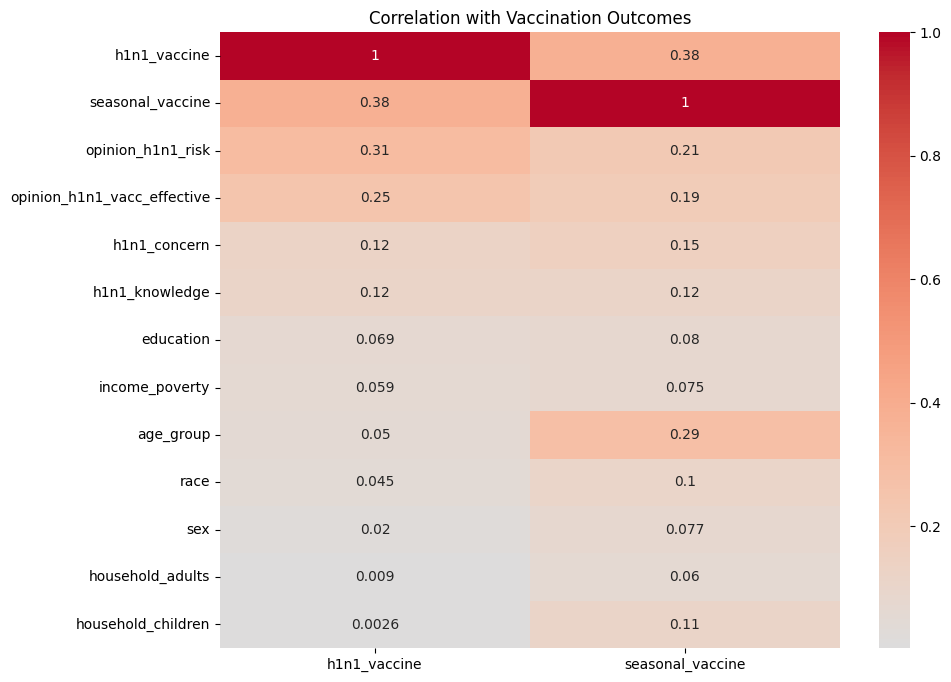

In [45]:
import matplotlib.pyplot as plt
from dython.nominal import associations

# 2. Define variable types
numerical = ['h1n1_concern', 'h1n1_knowledge', 'opinion_h1n1_vacc_effective',
            'opinion_h1n1_risk', 'household_adults', 'household_children']

categorical = ['age_group', 'education', 'race', 'sex', 'income_poverty']

binary_targets = ['h1n1_vaccine', 'seasonal_vaccine']

# 3. Compute associations using dython (handles mixed data types)
assoc = associations(
    train_data[numerical + categorical + binary_targets],
    nominal_columns=categorical + binary_targets,
    plot=False,
    compute_only=True
)

# 4. Visualize correlations with targets
target_corrs = assoc['corr'][['h1n1_vaccine', 'seasonal_vaccine']].sort_values(
    'h1n1_vaccine', ascending=False)

plt.figure(figsize=(10, 8))
plt.title("Correlation with Vaccination Outcomes")
sns.heatmap(target_corrs, annot=True, cmap='coolwarm', center=0)
plt.show()


In [46]:
education_order = [
    '< 12 Years', '12 Years', 'Some College', 'College Graduate'
]

train_data['education_ord'] = train_data['education'].map(
    lambda x: education_order.index(x) if x in education_order else -1
)

print(train_data[['education_ord', 'h1n1_vaccine']].corr(method='spearman'))


               education_ord  h1n1_vaccine
education_ord       1.000000      0.068458
h1n1_vaccine        0.068458      1.000000


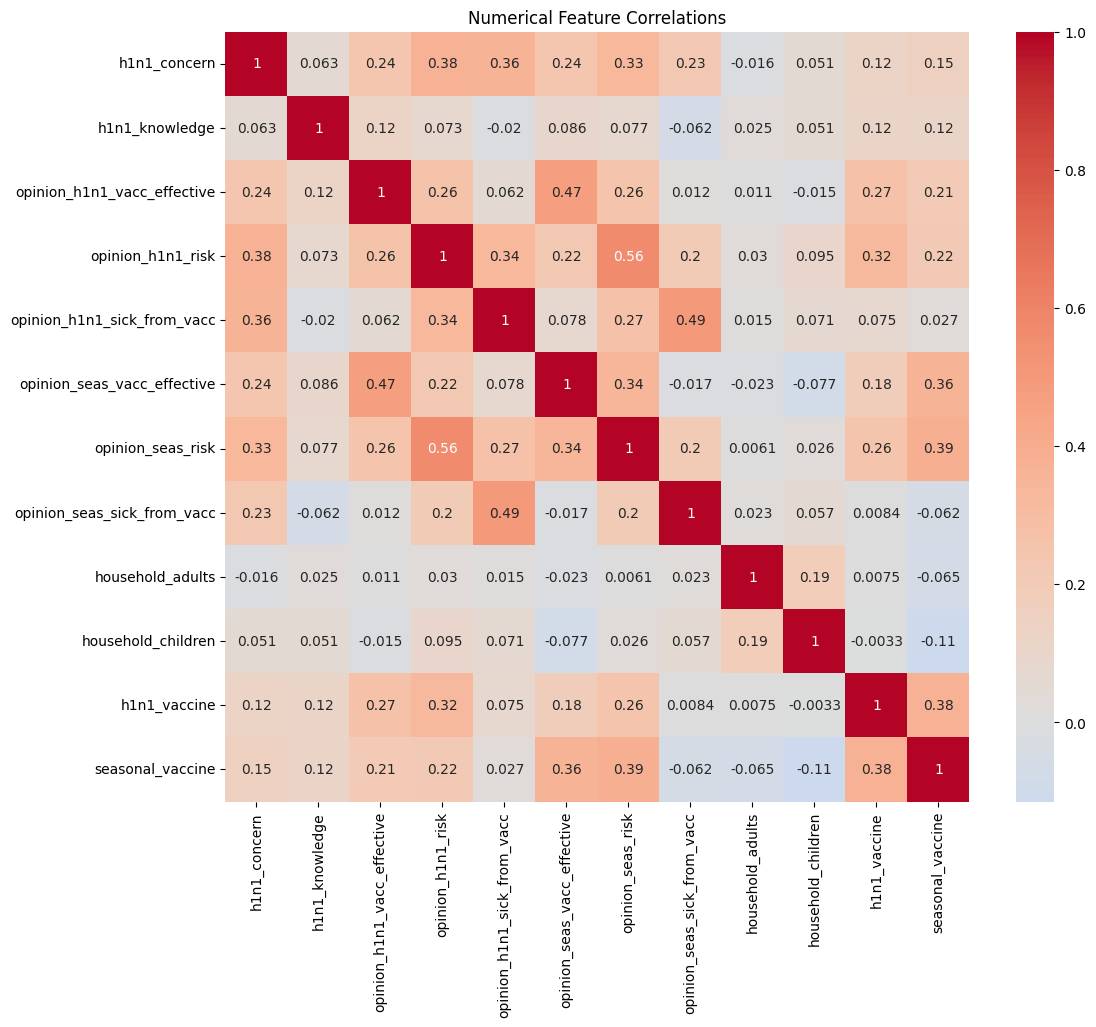

c:\Users\ReDi_NRW_6616\Desktop\Project-A_Data-Circle\myenv\Lib\site-packages\dython\nominal.py:558: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(nan_replace_value, inplace=True)


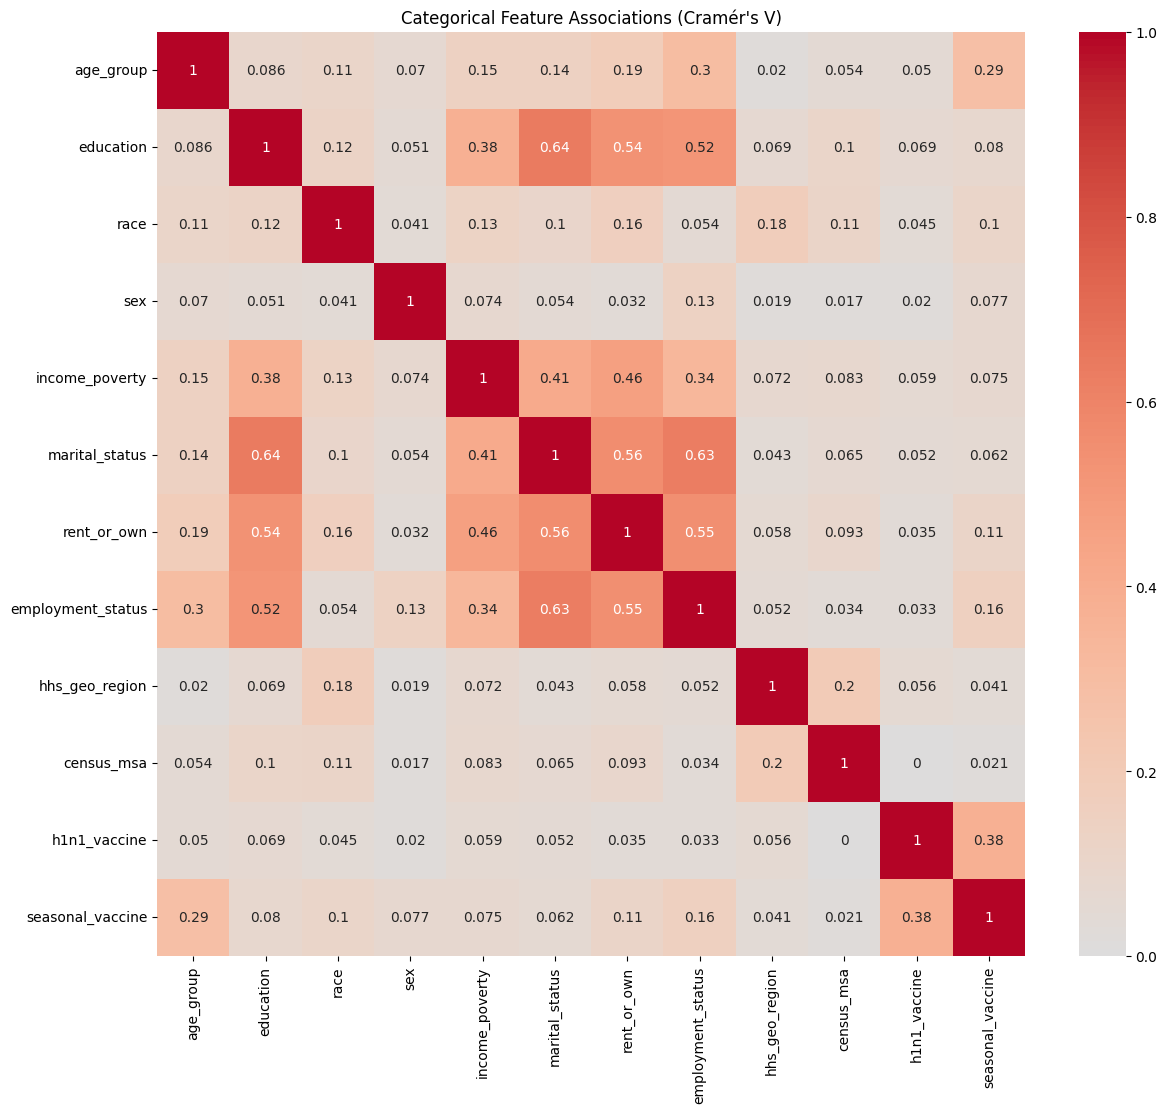

c:\Users\ReDi_NRW_6616\Desktop\Project-A_Data-Circle\myenv\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\ReDi_NRW_6616\Desktop\Project-A_Data-Circle\myenv\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


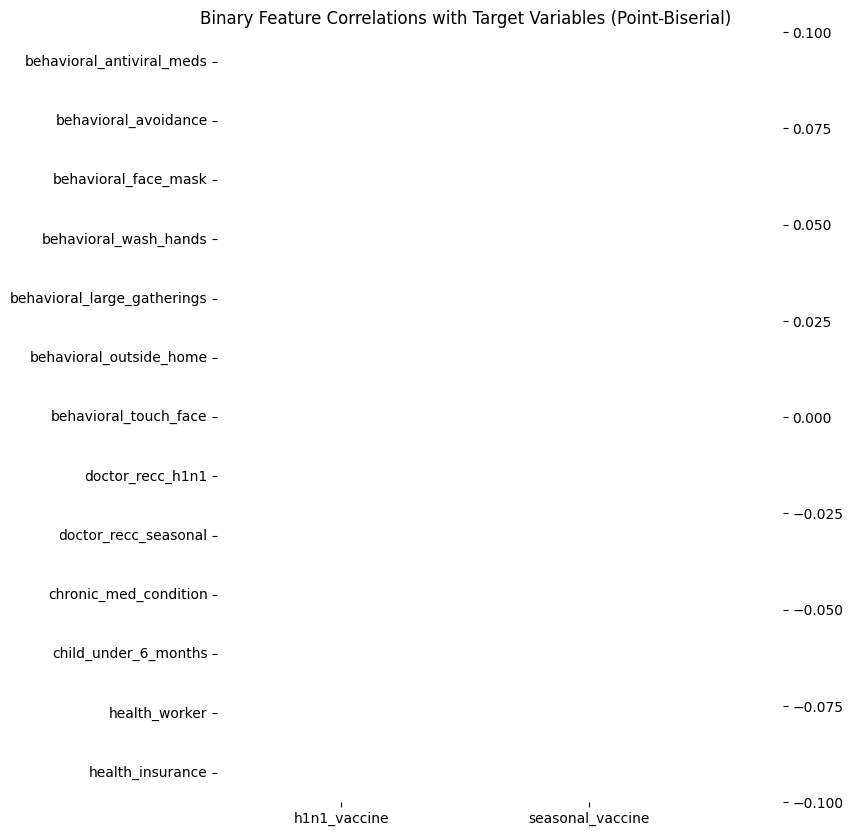

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr, spearmanr
from dython.nominal import associations

# Define variable types
numerical = [
    'h1n1_concern', 'h1n1_knowledge', 'opinion_h1n1_vacc_effective',
    'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc',
    'opinion_seas_vacc_effective', 'opinion_seas_risk',
    'opinion_seas_sick_from_vacc', 'household_adults', 'household_children'
]

categorical = ['age_group', 'education', 'race', 'sex', 'income_poverty',
               'marital_status', 'rent_or_own', 'employment_status',
               'hhs_geo_region', 'census_msa']

binary = [
    'behavioral_antiviral_meds', 'behavioral_avoidance',
    'behavioral_face_mask', 'behavioral_wash_hands',
    'behavioral_large_gatherings', 'behavioral_outside_home',
    'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
    'chronic_med_condition', 'child_under_6_months', 'health_worker',
    'health_insurance'
]

target = ['h1n1_vaccine', 'seasonal_vaccine']

# 1. Numerical Features Correlation
num_corr = train_data[numerical + target].corr(method='pearson')
plt.figure(figsize=(12, 10))
sns.heatmap(num_corr, annot=True, cmap='coolwarm', center=0)
plt.title("Numerical Feature Correlations")
plt.show()

# 2. Categorical Features Association (Cramér's V)
cat_data = train_data[categorical + target].copy() # Create a copy to avoid modifying the original DataFrame

# Convert target variables to 'object' dtype for categorical association
cat_data['h1n1_vaccine'] = cat_data['h1n1_vaccine'].astype('object')
cat_data['seasonal_vaccine'] = cat_data['seasonal_vaccine'].astype('object')

# Create a list of nominal columns that includes target variables
nominal_columns = categorical + target

cat_assoc = associations(cat_data, nominal_columns=nominal_columns, plot=False, compute_only=True)
plt.figure(figsize=(14, 12))
sns.heatmap(cat_assoc['corr'], annot=True, cmap='coolwarm', center=0)
plt.title("Categorical Feature Associations (Cramér's V)")
plt.show()

# 3. Binary Features (Point-Biserial with Target)
binary_target_corrs = {}
for bin_col in binary:
    h1n1_corr, _ = pointbiserialr(train_data[bin_col], train_data['h1n1_vaccine'])
    seas_corr, _ = pointbiserialr(train_data[bin_col], train_data['seasonal_vaccine'])
    binary_target_corrs[bin_col] = {'h1n1_vaccine': h1n1_corr, 'seasonal_vaccine': seas_corr}

binary_target_train_data = pd.DataFrame(binary_target_corrs).T
plt.figure(figsize=(8, 10))
sns.heatmap(binary_target_train_data, annot=True, cmap='coolwarm', center=0)
plt.title("Binary Feature Correlations with Target Variables (Point-Biserial)")
plt.show()


##### 2- Generate correlation heatmaps with hierarchical clustering

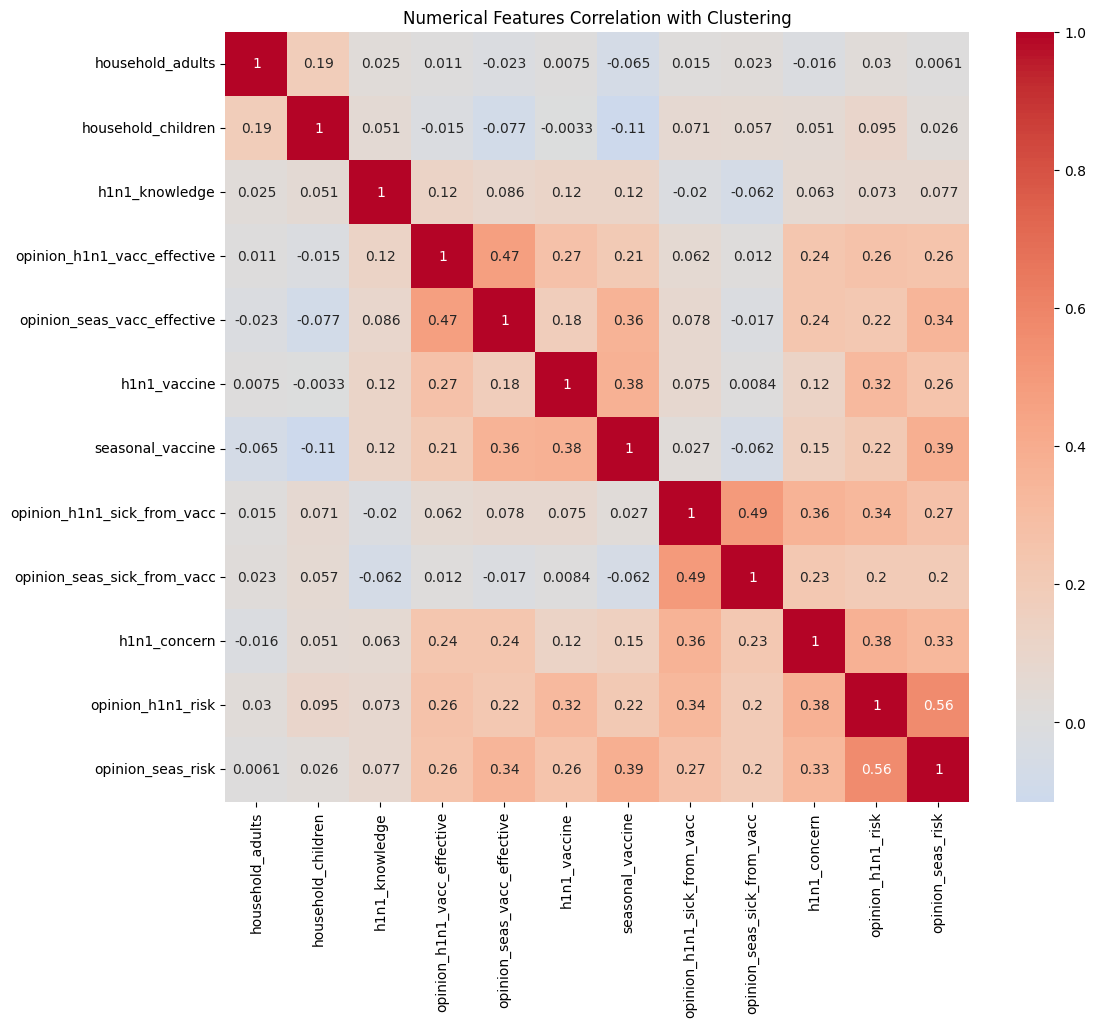

c:\Users\ReDi_NRW_6616\Desktop\Project-A_Data-Circle\myenv\Lib\site-packages\dython\nominal.py:558: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(nan_replace_value, inplace=True)


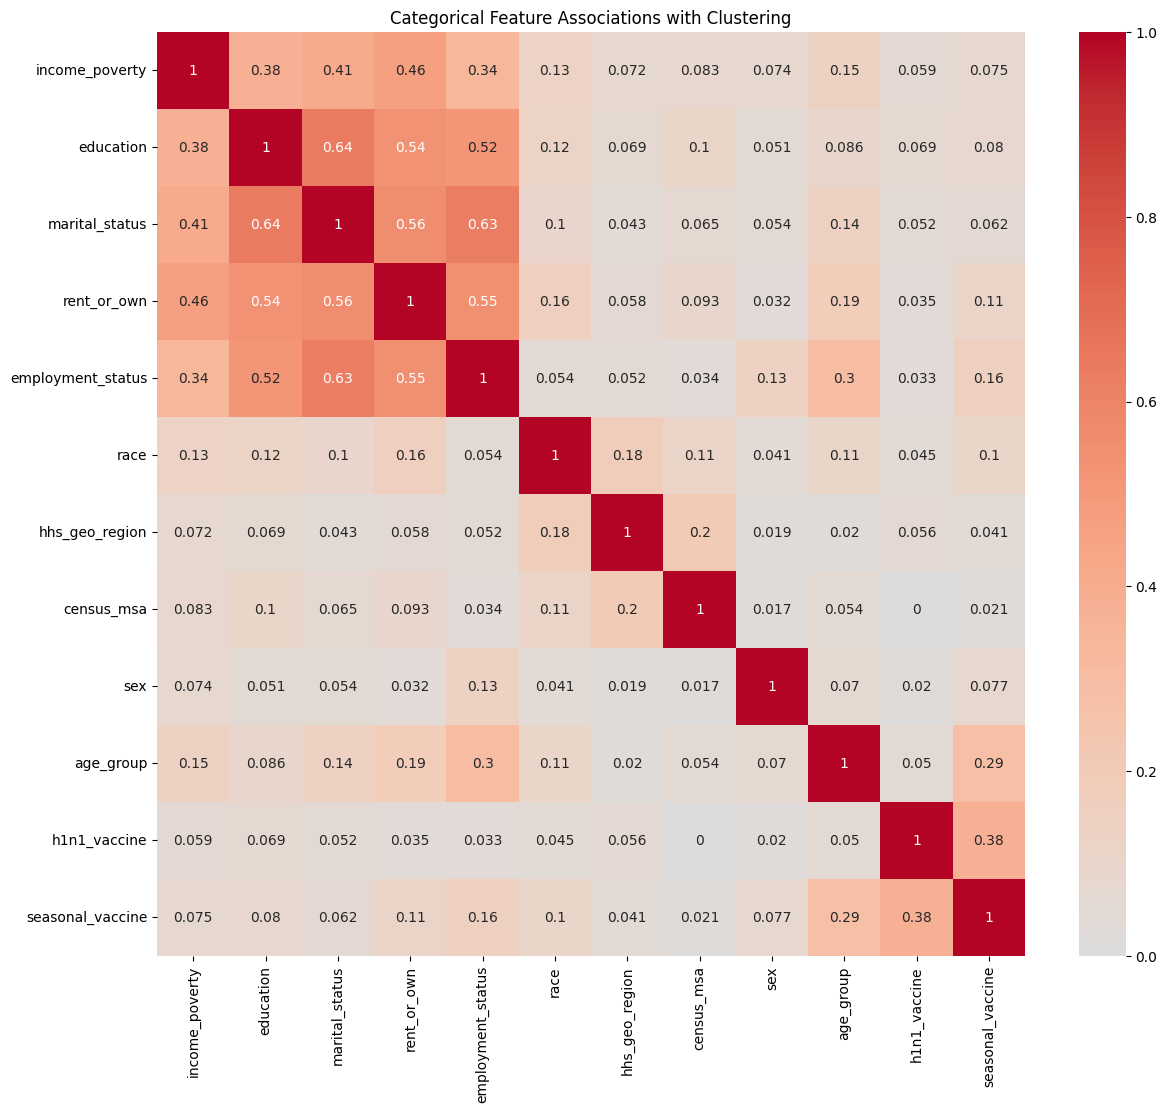

ValueError: The condensed distance matrix must contain only finite values.

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr, spearmanr
from dython.nominal import associations
from scipy.cluster.hierarchy import linkage, leaves_list

# Define variable types
numerical = [
    'h1n1_concern', 'h1n1_knowledge', 'opinion_h1n1_vacc_effective',
    'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc',
    'opinion_seas_vacc_effective', 'opinion_seas_risk',
    'opinion_seas_sick_from_vacc', 'household_adults', 'household_children'
]

categorical = ['age_group', 'education', 'race', 'sex', 'income_poverty',
               'marital_status', 'rent_or_own', 'employment_status',
               'hhs_geo_region', 'census_msa']

binary = [
    'behavioral_antiviral_meds', 'behavioral_avoidance',
    'behavioral_face_mask', 'behavioral_wash_hands',
    'behavioral_large_gatherings', 'behavioral_outside_home',
    'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
    'chronic_med_condition', 'child_under_6_months', 'health_worker',
    'health_insurance'
]

target = ['h1n1_vaccine', 'seasonal_vaccine']

# Function for hierarchical clustering and heatmap
def clustered_heatmap(train_data, title):
    corr = train_data.corr()
    linkage_matrix = linkage(corr)
    idx = leaves_list(linkage_matrix)
    corr_reordered = corr.iloc[idx, idx]

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_reordered, annot=True, cmap='coolwarm', center=0)
    plt.title(title)
    plt.show()

# 1. Numerical Features
clustered_heatmap(train_data[numerical + target], "Numerical Features Correlation with Clustering")

# 2. Categorical Features (using dython's associations)
cat_data = train_data[categorical + target].copy()
cat_data['h1n1_vaccine'] = cat_data['h1n1_vaccine'].astype('object')
cat_data['seasonal_vaccine'] = cat_data['seasonal_vaccine'].astype('object')
nominal_columns = categorical + target

cat_assoc = associations(cat_data, nominal_columns=nominal_columns, plot=False, compute_only=True)
cat_corr = cat_assoc['corr']

# Perform hierarchical clustering
linkage_matrix = linkage(cat_corr, method='ward')  # 'ward' minimizes variance
idx = leaves_list(linkage_matrix)  # get the order of the leaves
cat_corr_reordered = cat_corr.iloc[idx, idx]

plt.figure(figsize=(14, 12))
sns.heatmap(cat_corr_reordered, annot=True, cmap='coolwarm', center=0)
plt.title("Categorical Feature Associations with Clustering")
plt.show()

# 3. Binary Features (Point-Biserial with Target)
binary_target_corrs = {}
for bin_col in binary:
    h1n1_corr, _ = pointbiserialr(train_data[bin_col], train_data['h1n1_vaccine'])
    seas_corr, _ = pointbiserialr(train_data[bin_col], train_data['seasonal_vaccine'])
    binary_target_corrs[bin_col] = {'h1n1_vaccine': h1n1_corr, 'seasonal_vaccine': seas_corr}

binary_target_train_data = pd.DataFrame(binary_target_corrs).T

# Perform hierarchical clustering
linkage_matrix = linkage(binary_target_train_data)
idx = leaves_list(linkage_matrix)
binary_target_train_data_reordered = binary_target_train_data.iloc[idx, :]

plt.figure(figsize=(8, 10))
sns.heatmap(binary_target_train_data_reordered, annot=True, cmap='coolwarm', center=0)
plt.title("Binary Feature Correlations with Target Variables (Point-Biserial) and Clustering")
plt.show()


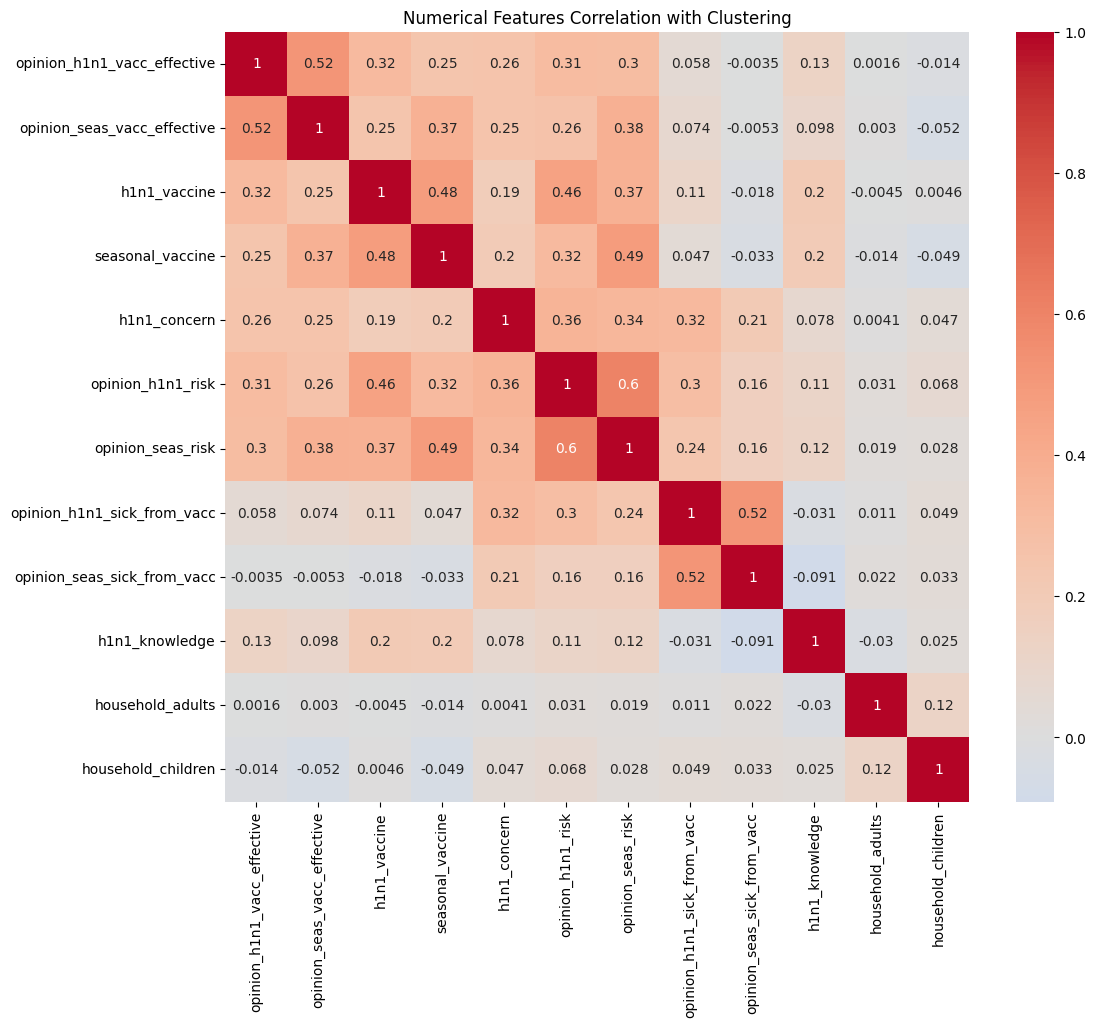

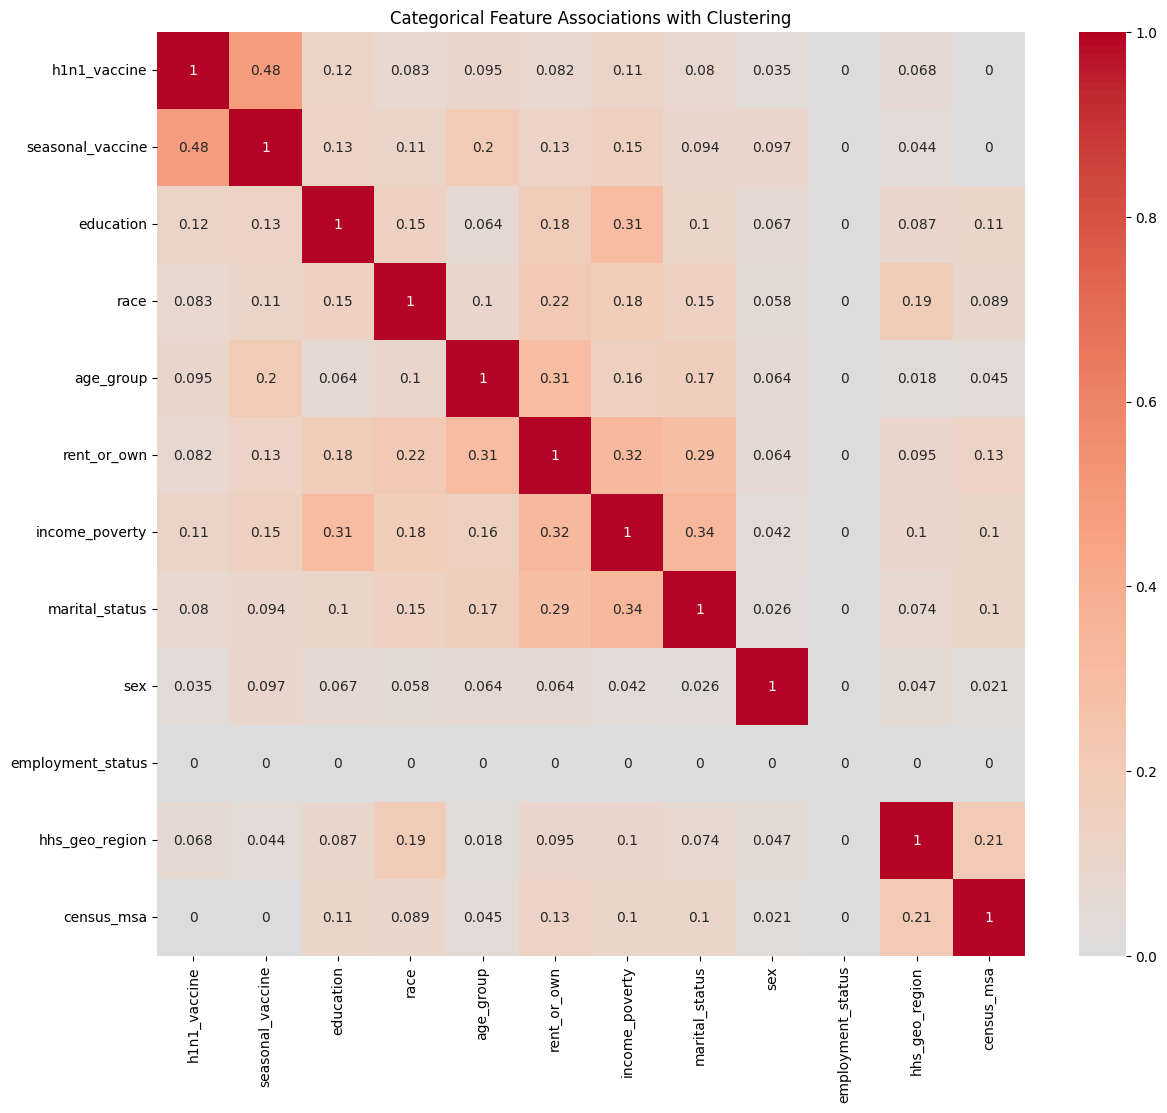

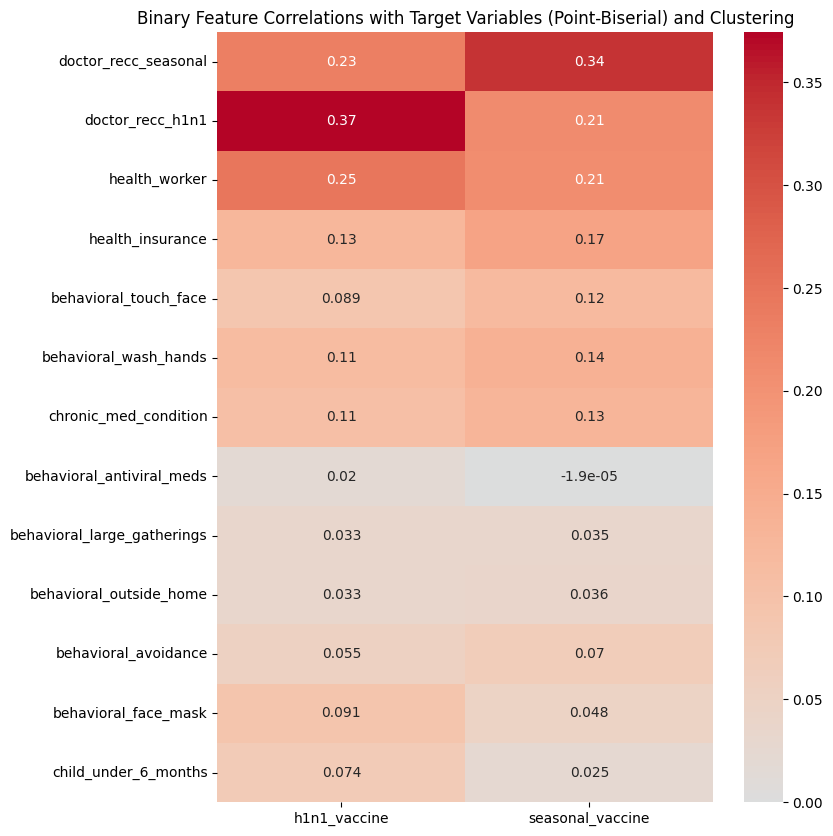

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr, spearmanr
from dython.nominal import associations
from scipy.cluster.hierarchy import linkage, leaves_list
import numpy as np

# Assuming train_data is your DataFrame
# train_data = pd.read_csv('your_data.csv') # if you still need to read

# Define variable types
numerical = [
    'h1n1_concern', 'h1n1_knowledge', 'opinion_h1n1_vacc_effective',
    'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc',
    'opinion_seas_vacc_effective', 'opinion_seas_risk',
    'opinion_seas_sick_from_vacc', 'household_adults', 'household_children'
]

categorical = ['age_group', 'education', 'race', 'sex', 'income_poverty',
               'marital_status', 'rent_or_own', 'employment_status',
               'hhs_geo_region', 'census_msa']

binary = [
    'behavioral_antiviral_meds', 'behavioral_avoidance',
    'behavioral_face_mask', 'behavioral_wash_hands',
    'behavioral_large_gatherings', 'behavioral_outside_home',
    'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
    'chronic_med_condition', 'child_under_6_months', 'health_worker',
    'health_insurance'
]

target = ['h1n1_vaccine', 'seasonal_vaccine']

# Clean data by removing all NA
train_data = train_data.dropna()

# Function for hierarchical clustering and heatmap
def clustered_heatmap(df, title):
    # Compute the correlation matrix
    corr = df.corr()

    # Remove rows and columns containing NaN values
    corr = corr.dropna(axis=0, how='any')
    corr = corr.dropna(axis=1, how='any')

    # Check if there are enough columns left to perform hierarchical clustering
    if corr.shape[1] <= 1:
        print(f"Not enough columns left for {title} after removing NaN values. Skipping clustering.")
        return

    # Perform hierarchical clustering
    linkage_matrix = linkage(corr, method='ward')
    idx = leaves_list(linkage_matrix)
    corr_reordered = corr.iloc[idx, idx]

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_reordered, annot=True, cmap='coolwarm', center=0)
    plt.title(title)
    plt.show()

# 1. Numerical Features
clustered_heatmap(train_data[numerical + target], "Numerical Features Correlation with Clustering")

# 2. Categorical Features (using dython's associations)
cat_data = train_data[categorical + target].copy()
cat_data['h1n1_vaccine'] = cat_data['h1n1_vaccine'].astype('object')
cat_data['seasonal_vaccine'] = cat_data['seasonal_vaccine'].astype('object')
nominal_columns = categorical + target

cat_assoc = associations(cat_data, nominal_columns=nominal_columns, plot=False, compute_only=True)
cat_corr = cat_assoc['corr']

cat_corr = cat_corr.dropna(axis=0, how='any')
cat_corr = cat_corr.dropna(axis=1, how='any')

# Perform hierarchical clustering
if cat_corr.shape[1] > 1:  # Ensure at least two columns remain
    linkage_matrix = linkage(cat_corr, method='ward')
    idx = leaves_list(linkage_matrix)
    cat_corr_reordered = cat_corr.iloc[idx, idx]

    plt.figure(figsize=(14, 12))
    sns.heatmap(cat_corr_reordered, annot=True, cmap='coolwarm', center=0)
    plt.title("Categorical Feature Associations with Clustering")
    plt.show()
else:
    print("Not enough columns left for Categorical Feature Associations after removing NaN values.")

# 3. Binary Features (Point-Biserial with Target)
binary_target_corrs = {}
for bin_col in binary:
    h1n1_corr, _ = pointbiserialr(train_data[bin_col], train_data['h1n1_vaccine'])
    seas_corr, _ = pointbiserialr(train_data[bin_col], train_data['seasonal_vaccine'])
    binary_target_corrs[bin_col] = {'h1n1_vaccine': h1n1_corr, 'seasonal_vaccine': seas_corr}

binary_target_df = pd.DataFrame(binary_target_corrs).T

binary_target_df = binary_target_df.dropna(axis=0, how='any')
binary_target_df = binary_target_df.dropna(axis=1, how='any')

if binary_target_df.shape[0] > 1:
    # Perform hierarchical clustering
    linkage_matrix = linkage(binary_target_df, method='ward')
    idx = leaves_list(linkage_matrix)
    binary_target_df_reordered = binary_target_df.iloc[idx, :]

    plt.figure(figsize=(8, 10))
    sns.heatmap(binary_target_df_reordered, annot=True, cmap='coolwarm', center=0)
    plt.title("Binary Feature Correlations with Target Variables (Point-Biserial) and Clustering")
    plt.show()
else:
    print("Not enough rows left for Binary Feature Correlations after removing NaN values.")


#### Ticket 1.4.2: Identify potentially redundant features

##### 1- Detect highly correlated feature pairs

##### 2- Recommend which features could be combined or removed

#### Ticket 1.4.3: Conduct preliminary feature importance analysis

##### 1- Use simple models to rank features by importance

##### 2- Compare feature importance between H1N1 and seasonal flu targets

#### Ticket 1.4.4: Document insights about which factors appear most influential

##### 1- Summarize key findings from correlation and importance analyses

##### 2- Identify unexpected or counterintuitive relationships

## Task.1.5: EDA Report Compilation

#### Ticket 1.5.1: Summarize key findings and insights


##### 1- Create an executive summary of important discoveries

##### 2- Connect insights to project goals and modeling approaches

#### Ticket 1.5.2: Compile all visualizations with clear explanations

##### 1- Create a visualization appendix with all exploratory plots

##### 2- Ensure all visualizations have proper titles and explanations

#### Ticket 1.5.3: Document preprocessing steps and rationale

##### 1- Create a methodology section describing cleaning approaches

##### 2- Address potential limitations or biases introduced during preprocessing

#### Ticket 1.5.4: Create presentation for Sprint 1 review

##### 1- Design 5-7 slides highlighting key finding

##### 2- Prepare speaking notes and anticipate questions